# RNA-seq comparison vs H3K4me3 and H3K36me3

In [1]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

sns.set_style("whitegrid")
import matplotlib.pyplot as plt
import numpy as np
import os
import pyranges as pr
from pyranges import PyRanges
import tempfile
from statannotations.Annotator import Annotator

sns.set_context("paper", rc={"font.size": 8})

In [2]:
def bedl(file):
    try:
        tf = pd.read_csv(file, sep='\t', header=None)
        return tf[2] - tf[1]
    except:
        return np.zeros(0)  # Empty file


def lines(file):
    try:
        tf = pd.read_csv(file, sep='\t', header=None)
        return len(tf)
    except:
        return 0  # Empty file


def d(a, b):
    return a / b if b != 0 else 0


def sorted_file(file):
    ts = tempfile.mktemp()
    ! cat {file} | sort -k1,1 -k2,2n > {ts}
    # Fixes of problems with peakseq output
    ! sed -E -i 's/[[:space:]]+/\t/g' {ts}
    ! sed -E -i 's/\t$//g' {ts}
    return ts


def sorted_file10(file):
    ts = tempfile.mktemp()
    ! cat {file} | cut -f1-10 | sort -k1,1 -k2,2n -k3,3n > {ts}
    # Fixes of problems with peakseq output
    ! sed -E -i 's/[[:space:]]+/\t/g' {ts}
    ! sed -E -i 's/\t$//g' {ts}
    return ts


def load_or_compute(path, compute):
    if os.path.exists(path):
        return pd.read_csv(path, sep='\t')
    else:
        df = compute()
        df.to_csv(path, sep='\t', index=False)
        return df

# Load peaks


In [3]:
GSE26320_PATH = os.path.expanduser('~/data/2023_GSE26320')
GSE26320_CELLS = ['GM12878', 'HMEC', 'HSMM', 'K562', 'NHEK', 'NHLF', 'H1', 'Huvec', 'HepG2']
MODIFICATIONS = ['H3K4me3', 'H3K36me3']
GSE26320_REPS = ['rep1', 'rep2']

IMMUNE_PATH = os.path.expanduser('~/data/2023_Immune')
IMMUNE_CELLS = ['CD4ABT', 'TCellBB', 'BCell', 'TCell', 'Monocyte', 'PBMC', 'NK', 'CD34', 'CD4', ]  ## Longest first
IMMUNE_REPS = ['rep1', 'rep2', 'rep3', '']

ABF_PATH = os.path.expanduser('~/data/2018_chipseq_y20o20')
ABF_MODIFICATIONS = ['k4me3', 'k27ac', 'k4me1', 'k27me3', 'k36me3']
ABF_REPLICATES = [f'OD{i}' for i in range(1, 30)] + [f'YD{i}' for i in range(1, 30)]

! mkdir -p {GSE26320_PATH}/pics
! mkdir -p {IMMUNE_PATH}/pics

In [4]:
import matplotlib.colors as mc
import colorsys


def adjust_lightness(c, amount=0.5):
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], max(0, min(1, amount * c[1])), c[2])


TOOLS = ['MACS2', 'SICER', 'Omnipeak', 'HOMER', 'Hotspot', 'Peakseq', 'LanceOtron']
palette = plt.get_cmap('tab10')
TOOLS_PALETTE = {t: palette(i) for i, t in enumerate(TOOLS)}

TOOLS_PALETTE['MACS2 broad'] = adjust_lightness(TOOLS_PALETTE['MACS2'])
TOOLS_PALETTE['HOMER histone'] = adjust_lightness(TOOLS_PALETTE['HOMER'])

TOOLS = ['MACS2', 'MACS2 broad', 'SICER', 'HOMER', 'HOMER histone', 'Hotspot', 'Peakseq', 'LanceOtron', 'Omnipeak']

In [5]:
def load_peaks(path, suffix, modifications, cells, replicates):
    df = pd.DataFrame(columns=['file', 'modification', 'cell', 'replicate', 'peaks'],
                      dtype=object)
    if not os.path.exists(path):
        return df
    for f in tqdm(os.listdir(path)):
        if not f.endswith(suffix):
            continue
        mod = next((m for m in modifications if f'{m}_' in f), None)
        cell = '' if '' in cells else next((c for c in cells if f'{c}_' in f), None)
        rep = next((r for r in replicates if f'_{r}_' in f or f'_{r}-' in f or f'_{r}.' in f or f.startswith(f'{r}_')),
                   None)
        if rep is None and '' in replicates:
            rep = ''
        if mod and cell is not None and rep is not None:
            peaks_path = os.path.join(path, f)
            ps = lines(peaks_path)
            df.loc[len(df)] = (peaks_path, mod, cell, rep, ps)
    return df

In [6]:
def load_peaks_path(path, modifications, cells, replicates):
    df_macs2 = load_peaks(os.path.join(path, 'macs2'), '.narrowPeak', modifications, cells, replicates)
    df_macs2['tool'] = 'MACS2'
    print('MACS2', len(df_macs2))

    df_macs2broad = load_peaks(os.path.join(path, 'macs2'), '.broadPeak', modifications, cells, replicates)
    df_macs2broad['tool'] = 'MACS2 broad'
    print('MACS2 broad', len(df_macs2broad))

    df_sicer = load_peaks(os.path.join(path, 'sicer'), 'summary-FDR0.01', modifications, cells, replicates)
    df_sicer['tool'] = 'SICER'
    print('SICER', len(df_sicer))

    df_omnipeak = load_peaks(os.path.join(path, 'omnipeak'), '.peak', modifications, cells, replicates)
    df_omnipeak['tool'] = 'Omnipeak'
    print('Omnipeak', len(df_omnipeak))

    df_homer = load_peaks(os.path.join(path, 'homer'), '_peaks.bed', modifications, cells, replicates)
    df_homer['tool'] = 'HOMER'
    print('HOMER', len(df_homer))

    df_homer_histone = load_peaks(os.path.join(path, 'homer'), '_regions.bed', modifications, cells, replicates)
    df_homer_histone['tool'] = 'HOMER histone'
    print('HOMER histone', len(df_homer_histone))

    df_hotspot = load_peaks(os.path.join(path, 'hotspot'), '.peak', modifications, cells, replicates)
    df_hotspot['tool'] = 'Hotspot'
    print('Hotspot', len(df_hotspot))

    df_peakseq = load_peaks(os.path.join(path, 'peakseq'), '.narrowPeak', modifications, cells, replicates)
    df_peakseq['tool'] = 'Peakseq'
    print('Peakseq', len(df_peakseq))

    df_lanceotron = load_peaks(os.path.join(path, 'lanceotron'), '.bed', modifications, cells, replicates)
    df_lanceotron['tool'] = 'LanceOtron'
    print('LanceOtron', len(df_lanceotron))

    return pd.concat(
        [df_macs2, df_macs2broad, df_sicer, df_omnipeak, df_homer, df_homer_histone, df_hotspot, df_peakseq,
         df_lanceotron]
    ).reset_index(drop=True)

In [7]:
df_encode_peaks = load_peaks_path(GSE26320_PATH, MODIFICATIONS, GSE26320_CELLS, GSE26320_REPS)
df_encode_peaks['dataset'] = 'ENCODE'
df_encode_peaks.sample(5)

  0%|          | 0/680 [00:00<?, ?it/s]

MACS2 33


  0%|          | 0/680 [00:00<?, ?it/s]

MACS2 broad 33


  0%|          | 0/85 [00:00<?, ?it/s]

...

  0%|          | 0/171 [00:00<?, ?it/s]

Peakseq 33


  0%|          | 0/170 [00:00<?, ?it/s]

LanceOtron 33


,file,modification,cell,replicate,peaks,tool,dataset
69,/home/jetbrains/data/2023_GSE26320/sicer/GSM64...,H3K36me3,H1,rep1,34574,SICER,ENCODE
251,/home/jetbrains/data/2023_GSE26320/peakseq/GSM...,H3K4me3,H1,rep2,20936,Peakseq,ENCODE
128,/home/jetbrains/data/2023_GSE26320/omnipeak/GS...,H3K36me3,Huvec,rep1,23876,Omnipeak,ENCODE
104,/home/jetbrains/data/2023_GSE26320/omnipeak/GS...,H3K4me3,NHLF,rep2,26061,Omnipeak,ENCODE
94,/home/jetbrains/data/2023_GSE26320/sicer/GSM64...,H3K4me3,Huvec,rep1,24595,SICER,ENCODE


In [8]:
df_immune_peaks = load_peaks_path(IMMUNE_PATH, MODIFICATIONS, IMMUNE_CELLS, IMMUNE_REPS)
df_immune_peaks['dataset'] = 'Roadmap'
df_immune_peaks.sample(5)

  0%|          | 0/368 [00:00<?, ?it/s]

MACS2 20


  0%|          | 0/368 [00:00<?, ?it/s]

MACS2 broad 20


  0%|          | 0/47 [00:00<?, ?it/s]

...

  0%|          | 0/94 [00:00<?, ?it/s]

Peakseq 20


  0%|          | 0/167 [00:00<?, ?it/s]

LanceOtron 20


,file,modification,cell,replicate,peaks,tool,dataset
139,/home/jetbrains/data/2023_Immune/hotspot/CD4AB...,H3K4me3,CD4ABT,rep1,68536,Hotspot,Roadmap
89,/home/jetbrains/data/2023_Immune/homer/CD34_H3...,H3K36me3,CD34,rep1,10247,HOMER,Roadmap
83,/home/jetbrains/data/2023_Immune/homer/CD4_H3K...,H3K36me3,CD4,rep1,710,HOMER,Roadmap
99,/home/jetbrains/data/2023_Immune/homer/CD34_H3...,H3K4me3,CD34,rep2,21482,HOMER,Roadmap
145,/home/jetbrains/data/2023_Immune/peakseq/PBMC_...,H3K36me3,PBMC,,92150,Peakseq,Roadmap


In [9]:
df_immune_peaks = load_peaks_path(IMMUNE_PATH, MODIFICATIONS, IMMUNE_CELLS, IMMUNE_REPS)
df_immune_peaks['dataset'] = 'Roadmap'
df_immune_peaks.sample(5)

  0%|          | 0/368 [00:00<?, ?it/s]

MACS2 20


  0%|          | 0/368 [00:00<?, ?it/s]

MACS2 broad 20


  0%|          | 0/47 [00:00<?, ?it/s]

...

  0%|          | 0/94 [00:00<?, ?it/s]

Peakseq 20


  0%|          | 0/167 [00:00<?, ?it/s]

LanceOtron 20


,file,modification,cell,replicate,peaks,tool,dataset
104,/home/jetbrains/data/2023_Immune/homer/CD34_H3...,H3K36me3,CD34,rep1,55954,HOMER histone,Roadmap
56,/home/jetbrains/data/2023_Immune/sicer/CD4ABT_...,H3K4me3,CD4ABT,rep2,23270,SICER,Roadmap
31,/home/jetbrains/data/2023_Immune/macs2/CD4_H3K...,H3K36me3,CD4,,107518,MACS2 broad,Roadmap
70,/home/jetbrains/data/2023_Immune/omnipeak/TCel...,H3K36me3,TCell,,34780,Omnipeak,Roadmap
66,/home/jetbrains/data/2023_Immune/omnipeak/CD4_...,H3K4me3,CD4,,24522,Omnipeak,Roadmap


In [10]:
df_abf_peaks_all = load_peaks_path(ABF_PATH, ABF_MODIFICATIONS, [''], ABF_REPLICATES)


def update_abf_modifications(df):
    df.loc[df['modification'] == 'k4me3', 'modification'] = 'H3K4me3'
    df.loc[df['modification'] == 'k27ac', 'modification'] = 'H3K27ac'
    df.loc[df['modification'] == 'k4me1', 'modification'] = 'H3K4me1'
    df.loc[df['modification'] == 'k27me3', 'modification'] = 'H3K27me3'
    df.loc[df['modification'] == 'k36me3', 'modification'] = 'H3K36me3'


update_abf_modifications(df_abf_peaks_all)

df_abf_peaks_all['cell'] = ['OD' if 'OD' in r else 'YD' for r in df_abf_peaks_all['replicate']]
df_abf_peaks_all['dataset'] = 'ABF'

# Drop outliers
ABF_OUTLIERS = {'k27ac': ['YD1', 'YD6'],
                'k27me3': ['OD9', 'YD1', 'YD2', 'YD3', 'YD4', 'YD9', 'YD10', 'YD11'],
                'k36me3': ['OD3', 'OD6', 'OD12', 'OD18', 'OD20', 'YD1', 'YD3', 'YD4', 'YD5'],
                'k4me3': ['OD6', 'OD7', 'OD14', 'YD2', 'YD3', 'YD10', 'YD14']}
t_outliers = [any(f'{o}_h3{m}'.lower() in f.lower() or f'{o}_{m}'.lower() in f.lower()
                  for m, ol in ABF_OUTLIERS.items() for o in ol)
              for f in df_abf_peaks_all['file']]
print('Total outliers', sum(t_outliers))
df_abf_peaks = df_abf_peaks_all[[not to for to in t_outliers]]

df_abf_peaks.sample(5)

  0%|          | 0/1528 [00:00<?, ?it/s]

MACS2 191


  0%|          | 0/1528 [00:00<?, ?it/s]

MACS2 broad 191


  0%|          | 0/191 [00:00<?, ?it/s]

...

  0%|          | 0/383 [00:00<?, ?it/s]

Peakseq 191


  0%|          | 0/542 [00:00<?, ?it/s]

LanceOtron 191
Total outliers 234


,file,modification,cell,replicate,peaks,tool,dataset
912,/home/jetbrains/data/2018_chipseq_y20o20/homer...,H3K4me3,OD,OD15,11646,HOMER,ABF
202,/home/jetbrains/data/2018_chipseq_y20o20/macs2...,H3K27me3,OD,OD19,80419,MACS2 broad,ABF
183,/home/jetbrains/data/2018_chipseq_y20o20/macs2...,H3K27ac,OD,OD10,87252,MACS2,ABF
1562,/home/jetbrains/data/2018_chipseq_y20o20/lance...,H3K27ac,OD,OD9,125265,LanceOtron,ABF
1435,/home/jetbrains/data/2018_chipseq_y20o20/peaks...,H3K27me3,OD,OD6,391508,Peakseq,ABF


In [11]:
df_peaks_full = pd.concat([df_encode_peaks, df_immune_peaks, df_abf_peaks]).reset_index(drop=True)

In [12]:
# Remove outliers, see 2_peaks.ipynb
OUTLIERS = [
    ('H3K4me3', 'NK', ''),
    ('H3K27ac', 'CD34', 'rep2'),
    ('H3K4me1', 'NK', ''),
    ('H3K27me3', 'BCell', ''),
    ('H3K27me3', 'TCell', ''),
    ('H3K27me3', 'NK', ''),
]
df_peaks = df_peaks_full.loc[[(m, c, r) not in OUTLIERS
                              for _, (m, c, r) in
                              df_peaks_full[['modification', 'cell', 'replicate']].iterrows()]].copy()

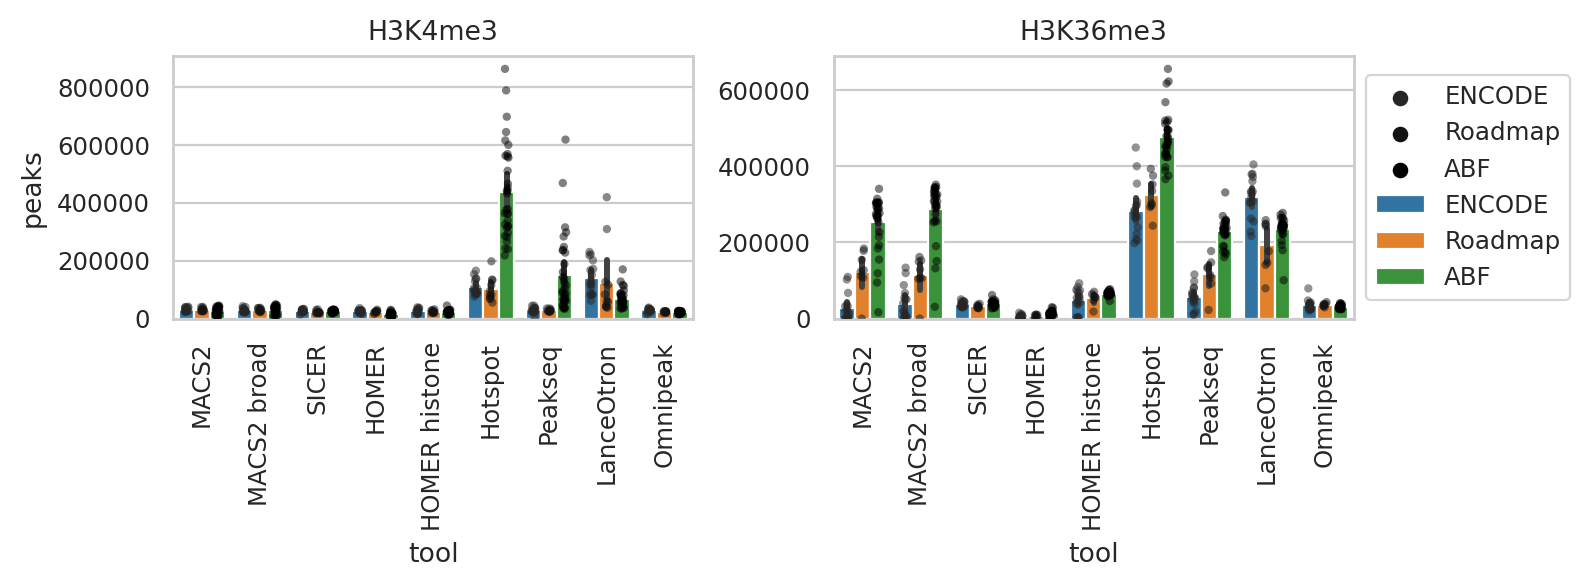

In [13]:
plt.figure(figsize=(8, 3))
axs = [plt.subplot(1, 2, i + 1) for i in range(2)]
for i, m in enumerate(MODIFICATIONS):
    ax = axs[i]
    sns.barplot(data=df_peaks[df_peaks['modification'] == m], x='tool', y='peaks', hue='dataset',
                # capsize=.2, err_kws={'linewidth': 2}, edgecolor="black",
                # palette=TOOLS_PALETTE,
                order=TOOLS,
                ax=ax)
    sns.stripplot(data=df_peaks[df_peaks['modification'] == m], x='tool', y='peaks', hue='dataset',
                  dodge=True, size=3, palette="dark:black", alpha=0.5,
                  order=TOOLS,
                  ax=ax)
    ax.xaxis.set_tick_params(rotation=90)
    ax.title.set_text(m)
    if i > 0:
        ax.set_ylabel(None)
    else:
        ax.set_ylabel('peaks')
    if i < 1:
        ax.legend().set_visible(False)
    else:
        # Put a legend to the right of the current axis
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    # ax.set_ylim(0, 1.9e7)
plt.tight_layout()
# plt.savefig(GSE26320_PATH_HG38 + f'/pics/library_mapped_detailed_all.pdf', bbox_inches='tight', dpi=300)
plt.show()

# RNA-seq vs

Benchmark according to the paper https://doi.org/10.1093/bib/bbw035
Features that define the best ChIP-seq peak calling algorithms

We considered a peak as positive if it overlaps the promoter of an expressed gene (RPKM > 0.5).
The top 15 000 peak calls from the different methods are ranked by their significance or by their fold enrichment for the thresholding method. We plotted the correct peak fraction (fraction of the top 1000xn peaks that overlap with active promoters) detected as a function of the correct promoter fraction (fraction of the active promoters that overlap with the top 1000xn peaks).

In [14]:
import re


def parse_gtf(gtf_path):
    print('Parse GTF aux data')
    gtf_df = pd.read_csv(gtf_path,
                         sep='\t', comment='#',
                         names=['chromosome', 'db', 'type', 'start', 'end', 'point1', 'strand', 'point2', 'aux'])

    auxes = {}
    for i, aux in enumerate(tqdm(gtf_df['aux'])):
        for pair in aux.split(';'):
            kv = pair.strip().split(' ')
            if len(kv) != 2:
                continue
            k, v = kv
            if k not in auxes:
                auxes[k] = vs = []
            else:
                vs = auxes[k]
            vs.append(v.strip('"'))

    for k, vs in auxes.items():
        if len(vs) == len(gtf_df):
            gtf_df[k] = vs
        else:
            print(f'Ignoring {k}')
    del auxes
    gtf_df.drop('aux', axis=1, inplace=True)

    print(len(gtf_df))
    # Fix . suffix in gene_id
    gtf_df['gene_id'] = [re.sub('\\..*', '', gid) for gid in gtf_df['gene_id']]
    return gtf_df


In [15]:
# V29 was used with RSEM for genes quantification in ENCODE pipeline

print('Processing hg38 GTF data')
gtf_hg38_df = parse_gtf(os.path.expanduser('~/data/gencode.v29.annotation.gtf'))
gtf_hg38_df.head(5)

Processing hg38 GTF data
Parse GTF aux data


  0%|          | 0/2742017 [00:00<?, ?it/s]

Ignoring havana_gene
Ignoring transcript_id
Ignoring transcript_type
Ignoring transcript_name
Ignoring transcript_support_level
Ignoring tag
Ignoring havana_transcript
Ignoring exon_number
Ignoring exon_id
Ignoring ont
Ignoring protein_id
Ignoring ccdsid
2742017


,chromosome,db,type,start,end,point1,strand,point2,gene_id,gene_type,gene_name,level
0,chr1,HAVANA,gene,11869,14409,.,+,.,ENSG00000223972,transcribed_unprocessed_pseudogene,DDX11L1,2
1,chr1,HAVANA,transcript,11869,14409,.,+,.,ENSG00000223972,transcribed_unprocessed_pseudogene,DDX11L1,2
2,chr1,HAVANA,exon,11869,12227,.,+,.,ENSG00000223972,transcribed_unprocessed_pseudogene,DDX11L1,2
3,chr1,HAVANA,exon,12613,12721,.,+,.,ENSG00000223972,transcribed_unprocessed_pseudogene,DDX11L1,2
4,chr1,HAVANA,exon,13221,14409,.,+,.,ENSG00000223972,transcribed_unprocessed_pseudogene,DDX11L1,2


In [16]:
print(f'Total hg38 records {len(gtf_hg38_df)}')
print(f'Total hg38 transcript {sum((gtf_hg38_df["type"] == "transcript"))}')
print(f'Total hg38 genes {sum((gtf_hg38_df["type"] == "gene"))}')
print(
    f'Total hg38 protein coding transcripts {sum((gtf_hg38_df["type"] == "gene") & (gtf_hg38_df["gene_type"] == "protein_coding"))}')
gtf_hg38_genes_df = gtf_hg38_df[(gtf_hg38_df["type"] == "gene")]

Total hg38 records 2742017
Total hg38 transcript 206694
Total hg38 genes 58721
Total hg38 protein coding transcripts 19940


In [17]:
print('Processing hg19 GTF data')
gtf_hg19_df = parse_gtf(os.path.expanduser('~/data/gencode.v19.annotation.gtf'))
gtf_hg19_df.head(5)

Processing hg19 GTF data
Parse GTF aux data


  0%|          | 0/2619444 [00:00<?, ?it/s]

Ignoring havana_gene
Ignoring tag
Ignoring havana_transcript
Ignoring exon_number
Ignoring exon_id
Ignoring ont
Ignoring protein_id
Ignoring ccdsid
2619444


,chromosome,db,type,start,end,point1,strand,point2,gene_id,transcript_id,gene_type,gene_status,gene_name,transcript_type,transcript_status,transcript_name,level
0,chr1,HAVANA,gene,11869,14412,.,+,.,ENSG00000223972,ENSG00000223972.4,pseudogene,KNOWN,DDX11L1,pseudogene,KNOWN,DDX11L1,2
1,chr1,HAVANA,transcript,11869,14409,.,+,.,ENSG00000223972,ENST00000456328.2,pseudogene,KNOWN,DDX11L1,processed_transcript,KNOWN,DDX11L1-002,2
2,chr1,HAVANA,exon,11869,12227,.,+,.,ENSG00000223972,ENST00000456328.2,pseudogene,KNOWN,DDX11L1,processed_transcript,KNOWN,DDX11L1-002,2
3,chr1,HAVANA,exon,12613,12721,.,+,.,ENSG00000223972,ENST00000456328.2,pseudogene,KNOWN,DDX11L1,processed_transcript,KNOWN,DDX11L1-002,2
4,chr1,HAVANA,exon,13221,14409,.,+,.,ENSG00000223972,ENST00000456328.2,pseudogene,KNOWN,DDX11L1,processed_transcript,KNOWN,DDX11L1-002,2


In [18]:
print(f'Total hg19 records {len(gtf_hg19_df)}')
print(f'Total hg19 transcript {sum((gtf_hg19_df["type"] == "transcript"))}')
print(f'Total hg19 genes {sum((gtf_hg19_df["type"] == "gene"))}')
print(
    f'Total hg19 protein coding transcripts {sum((gtf_hg19_df["type"] == "gene") & (gtf_hg19_df["gene_type"] == "protein_coding"))}')
gtf_hg19_genes_df = gtf_hg19_df[(gtf_hg19_df["type"] == "gene")]

Total hg19 records 2619444
Total hg19 transcript 196520
Total hg19 genes 57820
Total hg19 protein coding transcripts 20345


## Annotate quanitified RNA-seq with positions

In [19]:
import re

GSE26320_RNASEQ_PATH = os.path.expanduser('~/data/2023_GSE26320_rnaseq')

GSE26320_EXPRESSION_TSV = {
    ('GM12878', 'rep1'): GSE26320_RNASEQ_PATH + '/GM12878_rep1_RNAseq_hg38_ENCFF723ICA.tsv',
    ('GM12878', 'rep2'): GSE26320_RNASEQ_PATH + '/GM12878_rep2_RNAseq_hg38_ENCFF418FIT.tsv',
    ('H1', 'rep1'): GSE26320_RNASEQ_PATH + '/H1_rep1_RNAseq_hg38_ENCFF093NEQ.tsv',
    ('H1', 'rep2'): GSE26320_RNASEQ_PATH + '/H1_rep1_RNAseq_hg38_ENCFF093NEQ.tsv',
    ('HMEC', 'rep1'): GSE26320_RNASEQ_PATH + '/HMEC_rep1_RNAseq_hg38_ENCFF292FVY.tsv',
    ('HMEC', 'rep2'): GSE26320_RNASEQ_PATH + '/HMEC_rep2_RNAseq_hg38_ENCFF219EZH.tsv',
    ('HSMM', 'rep1'): GSE26320_RNASEQ_PATH + '/HSMM_rep1_RNAseq_hg38_ENCFF551YKI.tsv',
    ('HSMM', 'rep2'): GSE26320_RNASEQ_PATH + '/HSMM_rep2_RNAseq_hg38_ENCFF497BUG.tsv',
    ('HepG2', 'rep1'): GSE26320_RNASEQ_PATH + '/HepG2_rep1_RNAseq_hg38_ENCFF773JNC.tsv',
    ('HepG2', 'rep2'): GSE26320_RNASEQ_PATH + '/HepG2_rep2_RNAseq_hg38_ENCFF570ZOT.tsv',
    ('Huvec', 'rep1'): GSE26320_RNASEQ_PATH + '/Huvec_rep1_RNAseq_hg38_ENCFF454MTF.tsv',
    ('Huvec', 'rep2'): GSE26320_RNASEQ_PATH + '/Huvec_rep2_RNAseq_hg38_ENCFF134FYP.tsv',
    ('K562', 'rep1'): GSE26320_RNASEQ_PATH + '/K562_rep1_RNAseq_hg38_ENCFF139IXQ.tsv',
    ('K562', 'rep2'): GSE26320_RNASEQ_PATH + '/K562_rep2_RNAseq_hg38_ENCFF088RDE.tsv',
    ('NHEK', 'rep1'): GSE26320_RNASEQ_PATH + '/NHEK_rep1_RNAseq_hg38_ENCFF004JWA.tsv',
    ('NHEK', 'rep2'): GSE26320_RNASEQ_PATH + '/NHEK_rep1_RNAseq_hg38_ENCFF004JWA.tsv',
    ('NHLF', 'rep1'): GSE26320_RNASEQ_PATH + '/NHLF_rep1_RNAseq_hg38_ENCFF577DEC.tsv',
    ('NHLF', 'rep2'): GSE26320_RNASEQ_PATH + '/NHLF_rep2_RNAseq_hg38_ENCFF412KNK.tsv'
}

In [20]:
IMMUNE_EXPRESSION_TSV = {
    ('BCell', ''): IMMUNE_PATH + '/expression/BCell_RNAseq_hg38_ENCFF947SKG.tsv',
    ('TCell', ''): IMMUNE_PATH + '/expression/TCell_RNAseq_hg38_ENCFF502AZI.tsv',
    ('Monocyte', ''): IMMUNE_PATH + '/expression/Monocyte_RNAseq_hg38_ENCFF408GAO.tsv',
}

## Prepare track with TSS / Bodies of expressed genes

In [21]:
def merge_genes(full_df):
    print('Merging overlapping regions', len(full_df))
    ts = []
    for chr in full_df['chromosome'].unique():
        t = full_df[full_df['chromosome'] == chr].sort_values(by=['start', 'end']).copy()
        cols = t.columns.difference(['start', 'end', 'chromosome', 'gene_id', 'strand'])
        grps = t['start'].sub(t['end'].shift()).gt(1).cumsum()
        gpby = t.groupby(grps)
        t = gpby.agg(dict(start='min', end='max')).join(gpby[cols].mean())
        t['chromosome'] = chr
        t['gene_id'] = 'merged'
        t['strand'] = '.'
        t = t[['chromosome', 'start', 'end', 'gene_id', 'strand', 'TPM']]
        ts.append(t)
    ts = pd.concat(ts).reset_index(drop=True)
    print('Reduced to', len(ts))
    return ts

In [22]:
TSS = 500  # TSS width
EXPRESSED = 12_000  # Top expressed protein coding genes


def prepare_expressed(expression_tsv):
    result_tss = {}
    result_gene = {}
    for (cell, rep), path in tqdm(expression_tsv.items()):
        t = pd.read_csv(path, sep='\t')
        # Fix . suffix in gene_id
        t['gene_id'] = [re.sub('\\..*', '', gid) for gid in t['gene_id']]
        t['name'] = f'{cell} {rep}'
        print(cell, rep, path, len(t))

        full_df = pd.merge(left=t, right=gtf_hg38_genes_df, left_on='gene_id', right_on='gene_id')
        print(f'Total genes with positions {len(full_df)}')

        # Compute expression threshold
        tpms = list(full_df['TPM'])
        if len(tpms) <= EXPRESSED:
            print('Not enough genes with locations to proceed')
        tpms.sort(reverse=True)
        threshold = tpms[min(EXPRESSED, len(tpms) - 1)]
        print(f'TOP {EXPRESSED} threshold {threshold}')

        # Save expressed genes
        full_df = full_df[full_df['TPM'] > threshold].copy()
        full_df.sort_values(by=['chromosome', 'start'], inplace=True)

        gene_path = path.replace('.tsv', f'_expr_bodies.bed')
        full_df[['chromosome', 'start', 'end', 'gene_id', 'strand', 'TPM']].to_csv(
            gene_path, sep='\t', index=False, header=None)
        print(f'Saved body expressed genes fom {cell} to {gene_path}')
        result_gene[(cell, rep)] = gene_path

        starts = [
            max(1, start - TSS if strand == '+' else end - TSS)
            for start, end, strand in zip(full_df['start'], full_df['end'], full_df['strand'])
        ]
        ends = [
            start + TSS if strand == '+' else end + TSS
            for start, end, strand in zip(full_df['start'], full_df['end'], full_df['strand'])
        ]
        full_df['start'] = starts
        full_df['end'] = ends
        full_df = full_df[['chromosome', 'start', 'end', 'gene_id', 'strand', 'TPM']]
        full_df.sort_values(by=['chromosome', 'start', 'end'], inplace=True)
        full_df = merge_genes(full_df)

        tss_path = path.replace('.tsv', f'_expr_tss{TSS}.bed')
        full_df.to_csv(tss_path, sep='\t', index=False, header=None)
        print(f'Saved TSS expressed genes fom {cell} to {tss_path}')
        result_tss[(cell, rep)] = tss_path
    return result_gene, result_tss

In [23]:
encode_expression, encode_tss_expression = prepare_expressed(GSE26320_EXPRESSION_TSV)

  0%|          | 0/18 [00:00<?, ?it/s]

GM12878 rep1 /home/jetbrains/data/2023_GSE26320_rnaseq/GM12878_rep1_RNAseq_hg38_ENCFF723ICA.tsv 59526
Total genes with positions 58811
TOP 12000 threshold 0.52
Saved body expressed genes fom GM12878 to /home/jetbrains/data/2023_GSE26320_rnaseq/GM12878_rep1_RNAseq_hg38_ENCFF723ICA_expr_bodies.bed
Merging overlapping regions 11960
Reduced to 10669
Saved TSS expressed genes fom GM12878 to /home/jetbrains/data/2023_GSE26320_rnaseq/GM12878_rep1_RNAseq_hg38_ENCFF723ICA_expr_tss500.bed
GM12878 rep2 /home/jetbrains/data/2023_GSE26320_rnaseq/GM12878_rep2_RNAseq_hg38_ENCFF418FIT.tsv 61471
Total genes with positions 57041
TOP 12000 threshold 0.51
Saved body expressed genes fom GM12878 to /home/jetbrains/data/2023_GSE26320_rnaseq/GM12878_rep2_RNAseq_hg38_ENCFF418FIT_expr_bodies.bed
Merging overlapping regions 11997
Reduced to 10699
Saved TSS expressed genes fom GM12878 to /home/jetbrains/data/2023_GSE26320_rnaseq/GM12878_rep2_RNAseq_hg38_ENCFF418FIT_expr_tss500.bed
H1 rep1 /home/jetbrains/data/202

In [24]:
immune_expression, immune_tss_expression = prepare_expressed(IMMUNE_EXPRESSION_TSV)

  0%|          | 0/3 [00:00<?, ?it/s]

BCell  /home/jetbrains/data/2023_Immune/expression/BCell_RNAseq_hg38_ENCFF947SKG.tsv 59526
Total genes with positions 58811
TOP 12000 threshold 1.76
Saved body expressed genes fom BCell to /home/jetbrains/data/2023_Immune/expression/BCell_RNAseq_hg38_ENCFF947SKG_expr_bodies.bed
Merging overlapping regions 11985
Reduced to 10681
Saved TSS expressed genes fom BCell to /home/jetbrains/data/2023_Immune/expression/BCell_RNAseq_hg38_ENCFF947SKG_expr_tss500.bed
TCell  /home/jetbrains/data/2023_Immune/expression/TCell_RNAseq_hg38_ENCFF502AZI.tsv 59526
Total genes with positions 58811
TOP 12000 threshold 2.37
Saved body expressed genes fom TCell to /home/jetbrains/data/2023_Immune/expression/TCell_RNAseq_hg38_ENCFF502AZI_expr_bodies.bed
Merging overlapping regions 12000
Reduced to 10729
Saved TSS expressed genes fom TCell to /home/jetbrains/data/2023_Immune/expression/TCell_RNAseq_hg38_ENCFF502AZI_expr_tss500.bed
Monocyte  /home/jetbrains/data/2023_Immune/expression/Monocyte_RNAseq_hg38_ENCFF40

In [25]:
ABF_TRANSCRIPTION_PATH = ABF_PATH + '/y20o20_transcription.csv'
abf_expression_df = pd.read_csv(ABF_TRANSCRIPTION_PATH, sep=';')
# Fix . suffix in gene_id
abf_expression_df['gene_id'] = [re.sub('\\..*', '', gid) for gid in abf_expression_df['gene_id']]
cols = []
for c in ABF_REPLICATES:
    if c in abf_expression_df.columns:
        abf_expression_df[c] = abf_expression_df[c].apply(lambda x: x.replace(',', '.'))
        abf_expression_df[c] = abf_expression_df[c].astype(float)
        cols.append(c)
abf_expression_df = abf_expression_df[['gene_id'] + cols]
abf_expression_df.sample(3)

,gene_id,OD1,OD2,OD3,OD4,OD5,OD6,OD10,OD11,OD12,...,YD7,YD12,YD14,YD15,YD16,YD17,YD18,YD19,YD20,YD21
60027,ENSG00000283376,3.754936,3.754936,3.754936,3.754936,3.754936,3.754936,3.754936,3.754936,4.164033,...,3.754936,3.754936,3.754936,3.754936,3.754936,3.754936,3.754936,3.754936,3.754936,3.754936
45129,ENSG00000255042,4.314969,4.285826,3.754936,4.601406,4.135984,4.496037,4.710833,3.754936,3.754936,...,4.675657,4.298745,4.279852,4.417206,4.299147,4.188839,4.522722,3.754936,4.629662,3.754936
38290,ENSG00000241815,3.754936,3.754936,3.754936,3.754936,3.754936,3.754936,3.754936,3.754936,3.754936,...,3.754936,3.754936,3.754936,3.754936,3.754936,3.754936,3.754936,3.754936,4.150901,3.754936


In [26]:
def prepare_expressed_abf(abf_expression_df, cols, path):
    result_tss = {}
    result_gene = {}
    for donor in tqdm(cols):
        if donor not in abf_expression_df.columns:
            continue
        cell = 'OD' if 'OD' in donor else 'YD'
        full_df = pd.merge(left=abf_expression_df[['gene_id', donor]], right=gtf_hg19_genes_df, left_on='gene_id',
                           right_on='gene_id')
        full_df.rename(columns={donor: 'TPM'}, inplace=True)
        print(f'Total genes with positions {len(full_df)}')

        # Compute expression threshold
        tpms = list(full_df['TPM'])
        if len(tpms) <= EXPRESSED:
            print('Not enough genes with locations to proceed')
        tpms.sort(reverse=True)
        threshold = tpms[min(EXPRESSED, len(tpms) - 1)]
        print(f'TOP {EXPRESSED} threshold {threshold}')

        # Save expressed genes
        full_df = full_df[full_df['TPM'] > threshold].copy()
        full_df.sort_values(by=['chromosome', 'start'], inplace=True)

        gene_path = path.replace('.csv', f'_{donor}_expr_bodies.bed')
        full_df[['chromosome', 'start', 'end', 'gene_id', 'strand', 'TPM']].to_csv(
            gene_path, sep='\t', index=False, header=None)
        print(f'Saved body expressed genes fom {donor} to {gene_path}')
        result_gene[(cell, donor)] = gene_path

        starts = [
            max(1, start - TSS if strand == '+' else end - TSS)
            for start, end, strand in zip(full_df['start'], full_df['end'], full_df['strand'])
        ]
        ends = [
            start + TSS if strand == '+' else end + TSS
            for start, end, strand in zip(full_df['start'], full_df['end'], full_df['strand'])
        ]
        full_df['start'] = starts
        full_df['end'] = ends
        full_df = full_df[['chromosome', 'start', 'end', 'gene_id', 'strand', 'TPM']]
        full_df.sort_values(by=['chromosome', 'start', 'end'], inplace=True)
        full_df = merge_genes(full_df)

        tss_path = path.replace('.csv', f'_{donor}_expr_tss{TSS}.bed')
        full_df.to_csv(tss_path, sep='\t', index=False, header=None)
        print(f'Saved TSS expressed genes fom {donor} to {tss_path}')
        result_tss[(cell, donor)] = tss_path
    return result_gene, result_tss


In [27]:
abf_expression, abf_tss_expression = prepare_expressed_abf(abf_expression_df, ABF_REPLICATES, ABF_TRANSCRIPTION_PATH)

  0%|          | 0/58 [00:00<?, ?it/s]

Total genes with positions 56439
TOP 12000 threshold 6.506483279
Saved body expressed genes fom OD1 to /home/jetbrains/data/2018_chipseq_y20o20/y20o20_transcription_OD1_expr_bodies.bed
Merging overlapping regions 11993
Reduced to 10860
Saved TSS expressed genes fom OD1 to /home/jetbrains/data/2018_chipseq_y20o20/y20o20_transcription_OD1_expr_tss500.bed
Total genes with positions 56439
TOP 12000 threshold 5.997724513
Saved body expressed genes fom OD2 to /home/jetbrains/data/2018_chipseq_y20o20/y20o20_transcription_OD2_expr_bodies.bed
Merging overlapping regions 11965
Reduced to 10826
Saved TSS expressed genes fom OD2 to /home/jetbrains/data/2018_chipseq_y20o20/y20o20_transcription_OD2_expr_tss500.bed
Total genes with positions 56439
TOP 12000 threshold 6.053536261
Saved body expressed genes fom OD3 to /home/jetbrains/data/2018_chipseq_y20o20/y20o20_transcription_OD3_expr_bodies.bed
Merging overlapping regions 11964
Reduced to 10838
Saved TSS expressed genes fom OD3 to /home/jetbrains/d

# H3K4me3 overlap vs tss expressed genes

In [28]:
def how_to_sort(peaks_file, tool):
    if tool.startswith('MACS2'):
        sort_col, ascending = peaks_file.columns[8], False
    elif tool == 'SICER':
        sort_col, ascending = peaks_file.columns[3], False
    elif tool.startswith('HOMER'):
        sort_col, ascending = peaks_file.columns[4], False
    elif tool == 'Hotspot':
        sort_col, ascending = peaks_file.columns[4], False
    elif tool == 'Peakseq':
        sort_col, ascending = peaks_file.columns[8], True
    elif tool == 'LanceOtron':
        sort_col, ascending = peaks_file.columns[4], False
    elif tool == 'Omnipeak':
        sort_col, ascending = peaks_file.columns[8], False
    else:
        sort_col, ascending = peaks_file.columns[4], False
    return sort_col, ascending

In [29]:
# Hg38 Recovered promoter fraction / Correct peak fraction
def promoter_fraction(df_peaks, expression_tss, peaks_min=1000, peaks_max=30_000, peaks_n=10):
    rows = []
    for _, (c, r, tool, file) in tqdm(list(df_peaks[df_peaks['modification'] == 'H3K4me3']
                                           [['cell', 'replicate', 'tool', 'file']].iterrows())):
        # print(c, r, tool, file)
        if (c, r) not in expression_tss:
            continue
        # print('read expression')
        tss_file = pr.read_bed(sorted_file10(expression_tss[c, r]))
        tss = len(tss_file)
        peaks_total = lines(file)
        if peaks_total == 0:
            for top in np.linspace(peaks_min, peaks_max, num=peaks_n):
                rows.append((c, r, top, tss, file, 0, 0, 0, tool))
            continue
        peaks_file = pr.read_bed(sorted_file10(file), as_df=True)
        sort_col, ascending = how_to_sort(peaks_file, tool)
        peaks_file.sort_values(by=sort_col, ascending=ascending, inplace=True)
        for top in np.linspace(peaks_min, peaks_max, num=peaks_n):
            t = PyRanges(peaks_file.head(int(top)).sort_values(
                by=['Chromosome', 'Start']))
            peaks = len(t)
            peaks_overlap = len(t.overlap(tss_file))
            tss_overlap = len(tss_file.overlap(t))
            rows.append((c, r, top, tss, file, peaks, peaks_overlap, tss_overlap, tool))

    df = pd.DataFrame(
        rows,
        columns=['cell', 'replicate', 'top', 'genes', 'peaks_file', 'peaks', 'pg', 'gp', 'tool'],
        dtype=object
    )
    df['p'] = (df['pg'] + df['gp']) / 2
    df['precision'] = [d(x, y) for x, y in zip(df['pg'], df['peaks'])]
    df['recall'] = [d(x, y) for x, y in zip(df['gp'], df['genes'])]
    df['f1'] = [
        2 / (d(1, s + 1e-10) + d(1, p + 1e-10))
        for s, p in zip(df['recall'], df['precision'])]
    return df

In [30]:
encode_cpf_df_path = GSE26320_PATH + '/encode_cpf_df.tsv'
encode_cpf_df = load_or_compute(encode_cpf_df_path, lambda: promoter_fraction(df_encode_peaks, encode_tss_expression))
encode_cpf_df.sort_values(by=['cell', 'replicate', 'tool', 'top'], inplace=True)
encode_cpf_df.sample(3)

,cell,replicate,top,genes,peaks_file,peaks,pg,gp,tool,p,precision,recall,f1
95,Huvec,rep2,17111.111111,10838,/home/jetbrains/data/2023_GSE26320/macs2/GSM64...,17111,8818,6345,MACS2,7581.5,0.515341,0.585440,0.548159
1165,H1,rep1,17111.111111,10845,/home/jetbrains/data/2023_GSE26320/peakseq/GSM...,17111,8729,7874,Peakseq,8301.5,0.510140,0.726049,0.599239
214,HMEC,rep1,13888.888889,10811,/home/jetbrains/data/2023_GSE26320/macs2/GSM64...,13888,9155,8130,MACS2 broad,8642.5,0.659202,0.752012,0.702555


In [31]:
immune_cpf_df_path = IMMUNE_PATH + '/immune_cpf_df.tsv'
immune_cpf_df = load_or_compute(immune_cpf_df_path, lambda: promoter_fraction(df_immune_peaks, immune_tss_expression))
immune_cpf_df.fillna('', inplace=True)
immune_cpf_df.sort_values(by=['cell', 'replicate', 'tool', 'top'], inplace=True)
immune_cpf_df.sample(3)

,cell,replicate,top,genes,peaks_file,peaks,pg,gp,tool,p,precision,recall,f1
34,Monocyte,,13888.888889,10629,/home/jetbrains/data/2023_Immune/macs2/Monocyt...,13888,8623,8057,MACS2 broad,8340.0,0.620896,0.758021,0.682640
171,Monocyte,,4222.222222,10629,/home/jetbrains/data/2023_Immune/homer/Monocyt...,4222,3589,3760,HOMER histone,3674.5,0.850071,0.353749,0.499596
49,BCell,,30000.000000,10681,/home/jetbrains/data/2023_Immune/macs2/BCell_H...,24118,9163,8511,MACS2 broad,8837.0,0.379924,0.796836,0.514526


In [32]:
abf_cpf_df_path = ABF_PATH + '/abf_cpf_df.tsv'
abf_cpf_df = load_or_compute(abf_cpf_df_path, lambda: promoter_fraction(df_abf_peaks, abf_tss_expression))
abf_cpf_df.sort_values(by=['cell', 'replicate', 'tool', 'top'], inplace=True)
abf_cpf_df.sample(3)

,cell,replicate,top,genes,peaks_file,peaks,pg,gp,tool,p,precision,recall,f1
331,OD,OD4,4222.222222,10843,/home/jetbrains/data/2018_chipseq_y20o20/macs2...,4222,2768,2467,MACS2 broad,2617.5,0.655613,0.227520,0.337809
1507,OD,OD20,23555.555556,10815,/home/jetbrains/data/2018_chipseq_y20o20/hotsp...,23555,11602,8017,Hotspot,9809.5,0.492549,0.741285,0.591845
1516,OD,OD3,20333.333333,10838,/home/jetbrains/data/2018_chipseq_y20o20/hotsp...,20333,10943,7794,Hotspot,9368.5,0.538189,0.719136,0.615642


ENCODE


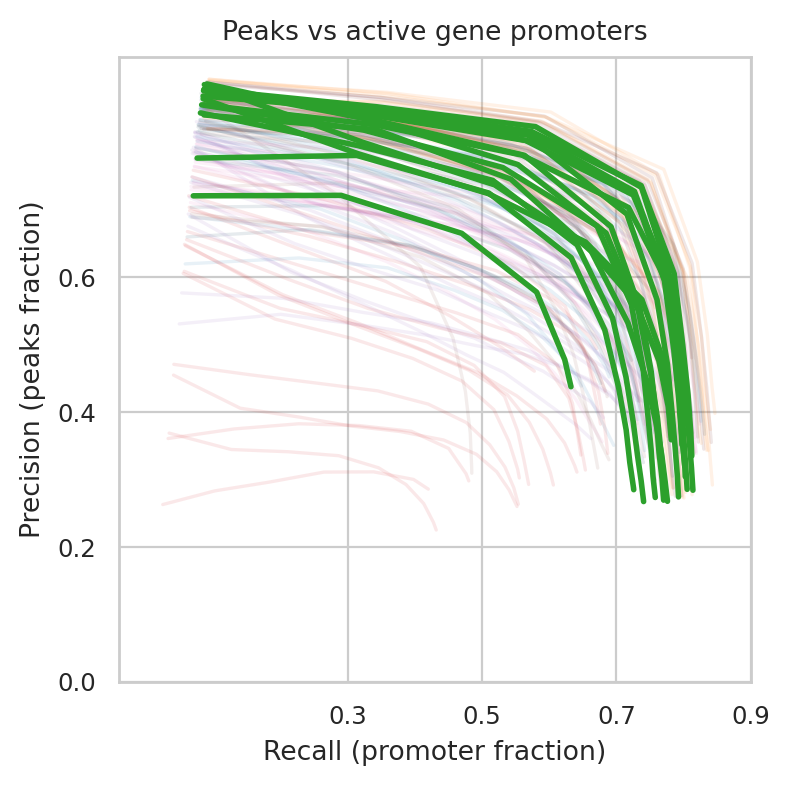

In [33]:
print('ENCODE')
plt.figure(figsize=(4, 4))
for (c, r, t), dft in encode_cpf_df[encode_cpf_df['tool'] != 'Omnipeak'].groupby(['cell', 'replicate', 'tool']):
    plt.plot(dft['recall'], dft['precision'], marker='', color=TOOLS_PALETTE[t], alpha=0.1)
for (c, r, t), dft in encode_cpf_df[encode_cpf_df['tool'] == 'Omnipeak'].groupby(['cell', 'replicate', 'tool']):
    plt.plot(dft['recall'], dft['precision'], marker='', color=TOOLS_PALETTE[t], alpha=1.0, linewidth=2)
plt.xticks(np.arange(0.3, 1, step=0.2))
plt.yticks(np.arange(0, 0.8, step=0.2))
plt.title('Peaks vs active gene promoters')
plt.xlabel('Recall (promoter fraction)')
plt.ylabel('Precision (peaks fraction)')
plt.tight_layout()
plt.show()

ENCODE


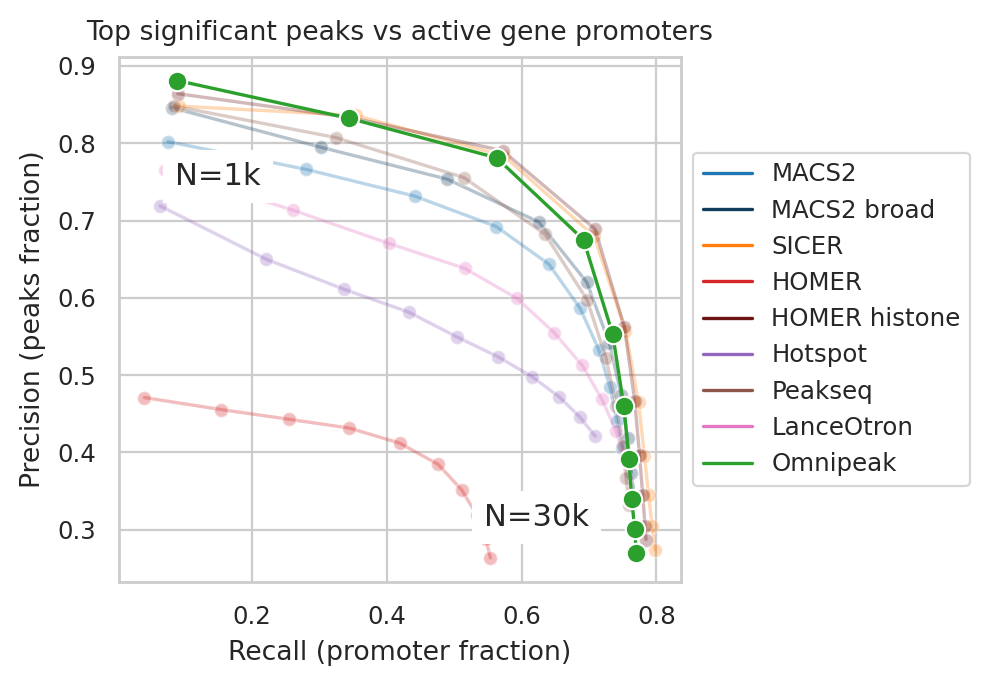

In [34]:
print('ENCODE')
plt.figure(figsize=(5, 3.5))
ax = plt.axes()
cr = encode_cpf_df[(encode_cpf_df['cell'] == 'K562') & (encode_cpf_df['replicate'] == 'rep1')]
sns.lineplot(data=cr[cr['tool'] != 'Omnipeak'],
             x='recall', y='precision', hue='tool', orient='y',
             alpha=0.3,
             hue_order=TOOLS,
             palette=TOOLS_PALETTE,
             marker='o', markersize=5,
             sort=False,
             ax=ax)
sns.lineplot(data=cr[cr['tool'] == 'Omnipeak'],
             x='recall', y='precision', hue='tool', orient='y',
             alpha=1.0,
             palette=TOOLS_PALETTE,
             marker='o', markersize=7,
             legend=False,
             sort=False,
             ax=ax)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.text(0.1, 0.80, "N=1k",
        transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(facecolor='white', alpha=1))
ax.text(0.65, 0.15, "N=30k",
        transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(facecolor='white', alpha=1))
# plt.xticks(np.arange(0.3, 1, step=0.2))
# plt.yticks(np.arange(0, 0.8, step=0.2))
plt.title('Top significant peaks vs active gene promoters')
plt.xlabel('Recall (promoter fraction)')
plt.ylabel('Precision (peaks fraction)')
plt.tight_layout()
plt.show()

Roadmap


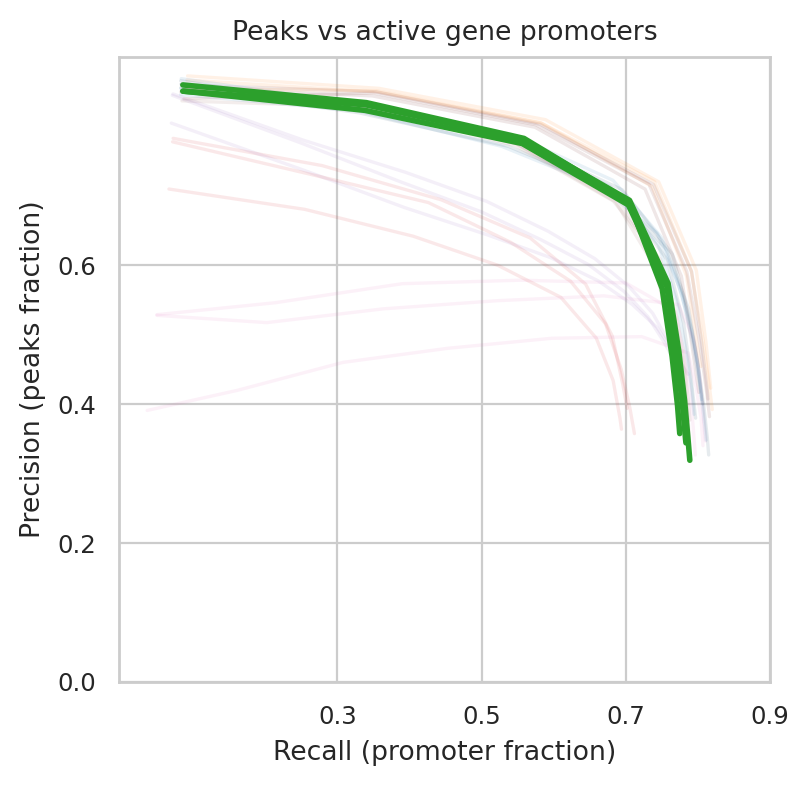

In [35]:
print('Roadmap')
plt.figure(figsize=(4, 4))
for (c, r, t), dft in immune_cpf_df[immune_cpf_df['tool'] != 'Omnipeak'].groupby(['cell', 'replicate', 'tool']):
    plt.plot(dft['recall'], dft['precision'], marker='', color=TOOLS_PALETTE[t], alpha=0.1)
for (c, r, t), dft in immune_cpf_df[immune_cpf_df['tool'] == 'Omnipeak'].groupby(['cell', 'replicate', 'tool']):
    plt.plot(dft['recall'], dft['precision'], marker='', color=TOOLS_PALETTE[t], alpha=1.0, linewidth=2)
plt.title('Peaks vs active gene promoters')
plt.xlabel('Recall (promoter fraction)')
plt.ylabel('Precision (peaks fraction)')
plt.tight_layout()
plt.xticks(np.arange(0.3, 1, step=0.2))
plt.yticks(np.arange(0, 0.8, step=0.2))
plt.show()

Roadmap


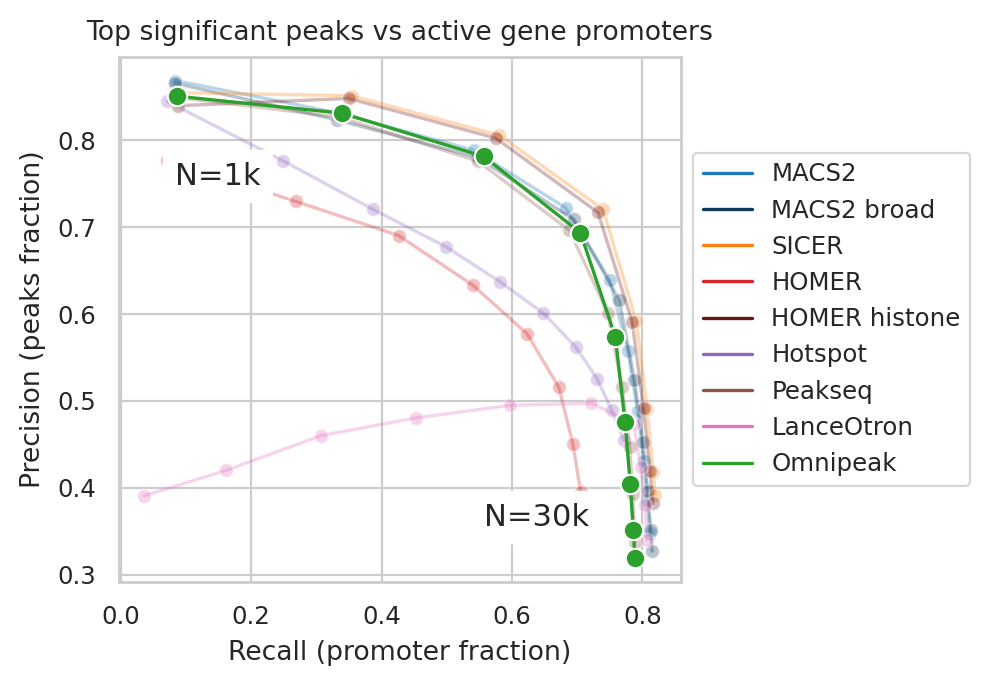

In [36]:
print('Roadmap')
plt.figure(figsize=(5, 3.5))
ax = plt.axes()
cr = immune_cpf_df[(immune_cpf_df['cell'] == 'TCell') & (immune_cpf_df['replicate'] == '')].copy()
sns.lineplot(data=cr[cr['tool'] != 'Omnipeak'],
             x='recall', y='precision', hue='tool', orient='y',
             alpha=0.3,
             hue_order=TOOLS,
             palette=TOOLS_PALETTE,
             marker='o', markersize=5,
             sort=False,
             ax=ax)
sns.lineplot(data=cr[cr['tool'] == 'Omnipeak'],
             x='recall', y='precision', hue='tool', orient='y',
             alpha=1.0,
             palette=TOOLS_PALETTE,
             marker='o', markersize=7,
             legend=False,
             sort=False,
             ax=ax)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# plt.xticks(np.arange(0.3, 1, step=0.2))
# plt.yticks(np.arange(0, 0.8, step=0.2))
ax.text(0.1, 0.80, "N=1k",
        transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(facecolor='white', alpha=1))
ax.text(0.65, 0.15, "N=30k",
        transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(facecolor='white', alpha=1))
plt.title('Top significant peaks vs active gene promoters')
plt.xlabel('Recall (promoter fraction)')
plt.ylabel('Precision (peaks fraction)')
plt.tight_layout()
plt.show()

ABF


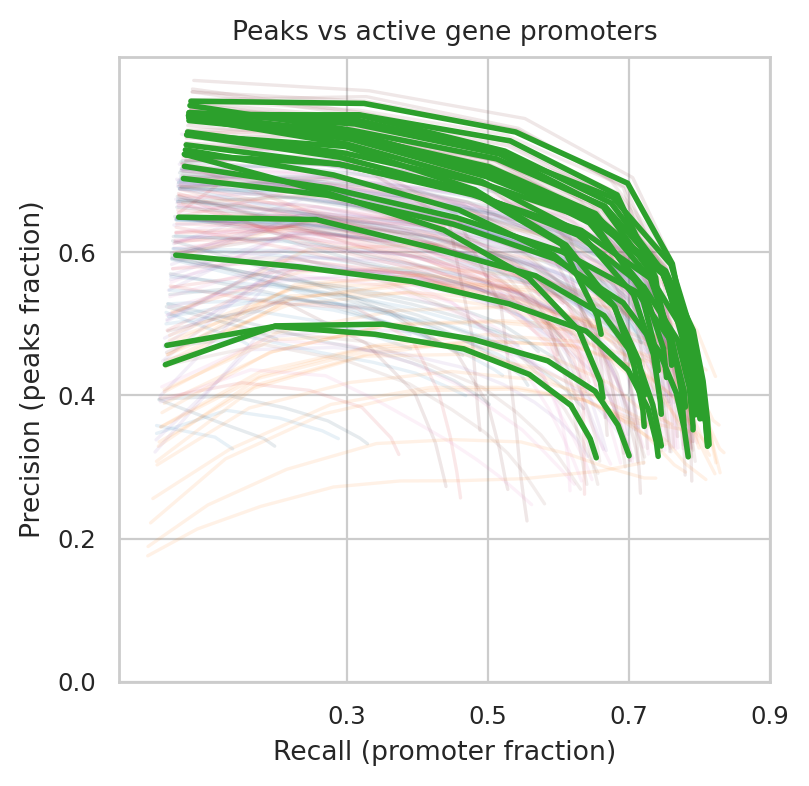

In [37]:
print('ABF')
plt.figure(figsize=(4, 4))
for (c, r, t), dft in abf_cpf_df[abf_cpf_df['tool'] != 'Omnipeak'].groupby(['cell', 'replicate', 'tool']):
    plt.plot(dft['recall'], dft['precision'], marker='', color=TOOLS_PALETTE[t], alpha=0.1)
for (c, r, t), dft in abf_cpf_df[abf_cpf_df['tool'] == 'Omnipeak'].groupby(['cell', 'replicate', 'tool']):
    plt.plot(dft['recall'], dft['precision'], marker='', color=TOOLS_PALETTE[t], alpha=1.0, linewidth=2)
plt.title('Peaks vs active gene promoters')
plt.xlabel('Recall (promoter fraction)')
plt.ylabel('Precision (peaks fraction)')
plt.tight_layout()
plt.xticks(np.arange(0.3, 1, step=0.2))
plt.yticks(np.arange(0, 0.8, step=0.2))
plt.show()

ABF


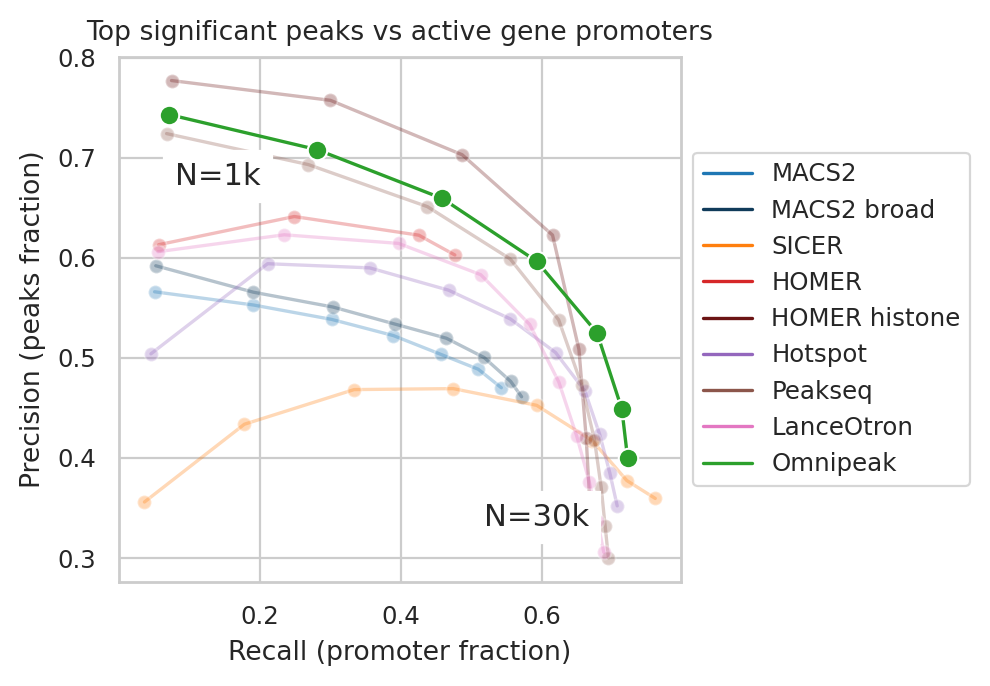

In [38]:
print('ABF')
plt.figure(figsize=(5, 3.5))
ax = plt.axes()
cr = abf_cpf_df[abf_cpf_df['replicate'] == 'OD12'].copy()
sns.lineplot(data=cr[cr['tool'] != 'Omnipeak'],
             x='recall', y='precision', hue='tool', orient='y',
             alpha=0.3,
             hue_order=TOOLS,
             palette=TOOLS_PALETTE,
             marker='o', markersize=5,
             sort=False,
             ax=ax)
sns.lineplot(data=cr[cr['tool'] == 'Omnipeak'],
             x='recall', y='precision', hue='tool', orient='y',
             alpha=1.0,
             palette=TOOLS_PALETTE,
             marker='o', markersize=7,
             legend=False,
             sort=False,
             ax=ax)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# plt.xticks(np.arange(0.3, 1, step=0.2))
# plt.yticks(np.arange(0, 0.8, step=0.2))
ax.text(0.1, 0.80, "N=1k",
        transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(facecolor='white', alpha=1))
ax.text(0.65, 0.15, "N=30k",
        transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(facecolor='white', alpha=1))
plt.title('Top significant peaks vs active gene promoters')
plt.xlabel('Recall (promoter fraction)')
plt.ylabel('Precision (peaks fraction)')
plt.tight_layout()
plt.show()

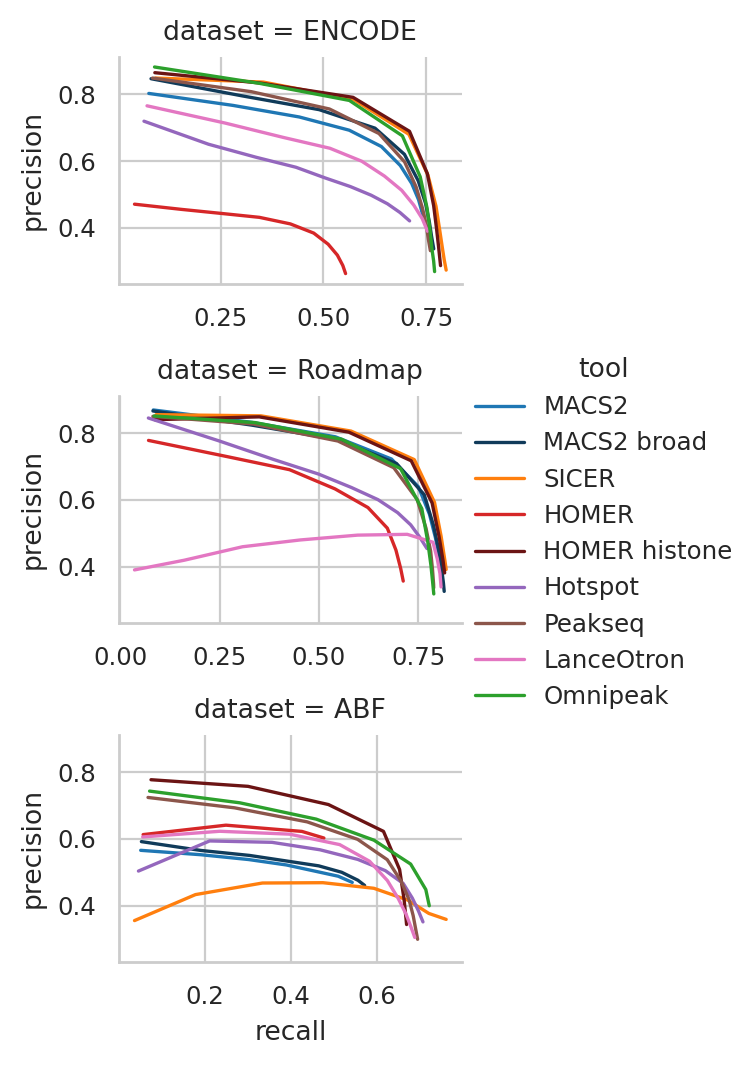

In [39]:
t1 = encode_cpf_df[(encode_cpf_df['cell'] == 'K562') & (encode_cpf_df['replicate'] == 'rep1')].copy()
t1['dataset'] = 'ENCODE'
t2 = immune_cpf_df[immune_cpf_df['cell'] == 'TCell'].copy()
t2['dataset'] = 'Roadmap'
t3 = abf_cpf_df[abf_cpf_df['replicate'] == 'OD12'].copy()
t3['dataset'] = 'ABF'

cr = pd.concat([t1, t2, t3]).reset_index(drop=True)

g = sns.FacetGrid(cr, hue="tool", row="dataset", height=1.8, aspect=1.5,
                  palette=TOOLS_PALETTE,
                  hue_order=TOOLS,
                  sharex=False)
g.map(sns.lineplot, "recall", "precision", sort=False)
g.add_legend()
plt.show()

## Average precision

One of the key limitations of AUROC becomes most apparent on highly imbalanced datasets
(low % of positives, lots of negatives), e.g. many medical datasets, rare event detection problems, etc.
Small changes in the number of false positives/false negatives can severely shift AUROC.
AUPR, which plots precision vs. recall is more robust to this problem.

AP (AUPR) summarizes a precision-recall curve as the weighted mean of precisions achieved at each threshold, with the increase in recall from the previous threshold used as the weight:

AP = ∑(Rn−Rn−1)*Pn, where  Pn and Rn are the precision and recall at the nth threshold.

This implementation is not interpolated and is different from computing the area under the precision-recall curve with the trapezoidal rule, which uses linear interpolation and can be too optimistic.

In [40]:
encode_cpf_df['dataset'] = 'ENCODE'
immune_cpf_df['dataset'] = 'Roadmap'
abf_cpf_df['dataset'] = 'ABF'
t = pd.concat([encode_cpf_df, immune_cpf_df, abf_cpf_df]).reset_index(drop=True)
rows = []
for (ds, c, r, tool), dft in t.groupby(['dataset', 'cell', 'replicate', 'tool']):
    ap = 0
    sprev, pprev = None, None
    for _, row in dft.iterrows():
        if sprev is not None and pprev is not None:
            ap += (row['recall'] - sprev) * (row['precision'] + pprev) / 2
        sprev, pprev = row['recall'], row['precision']
    rows.append((ds, c, r, tool, ap))
aps_df = pd.DataFrame(rows, columns=['dataset', 'cell', 'replicate', 'tool', 'auc'])
del rows
aps_df.sample(3)

,dataset,cell,replicate,tool,auc
301,ENCODE,HepG2,rep2,MACS2,0.544693
335,ENCODE,K562,rep2,Hotspot,0.418162
378,Roadmap,Monocyte,,HOMER,0.395047


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

ENCODE_LanceOtron vs. ENCODE_Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:4.434e-03 U_stat=5.200e+01
ABF_LanceOtron vs. ABF_Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:3.391e-03 U_stat=1.610e+02
ABF_Hotspot vs. ABF_Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:6.850e-04 U_stat=1.370e+02
ENCODE_Hotspot vs. ENCODE_Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:5.973e-05 U_stat=2.100e+01
ABF_HOMER vs. ABF_Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:3.580e-08 U_stat=2.800e+01
ENCODE_HOMER vs. ENCODE_Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val

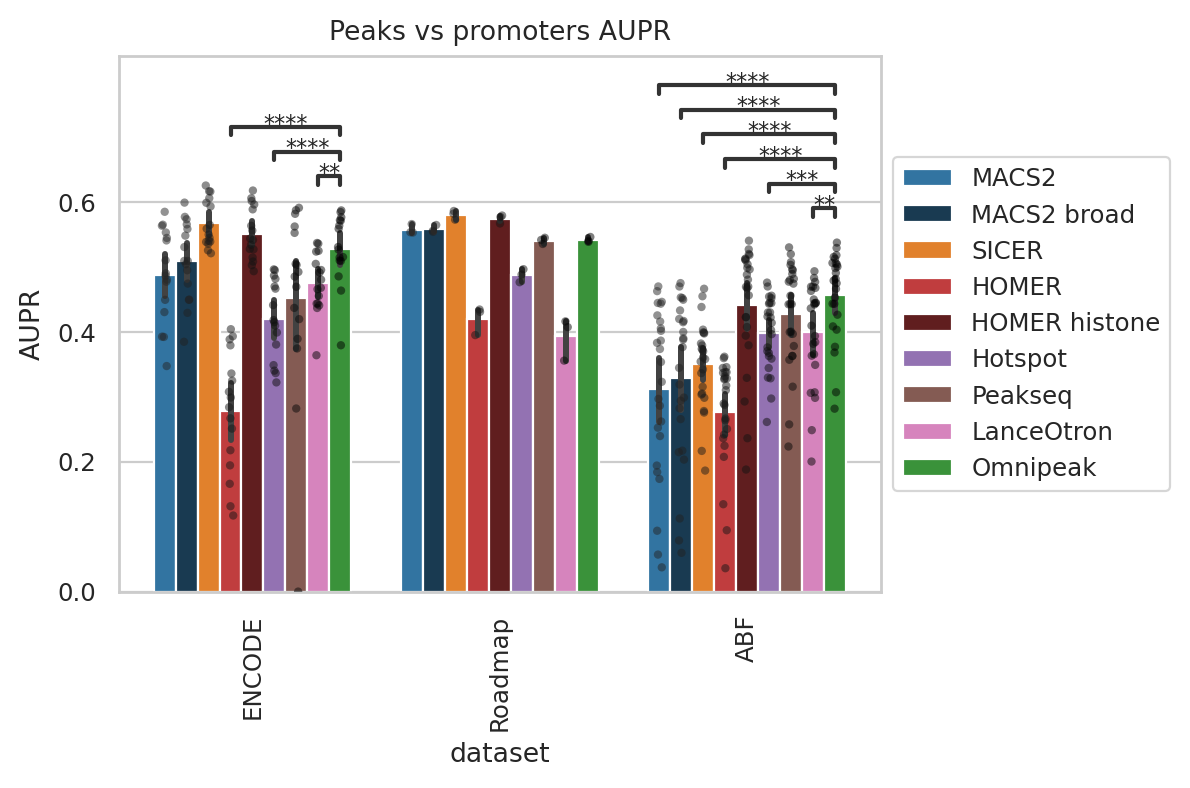

In [41]:
from itertools import product

datasets = ['ENCODE', 'Roadmap', 'ABF']
plt.figure(figsize=(6, 4))
ax = plt.axes()
ax.title.set_text('Peaks vs promoters AUPR')
sns.barplot(data=aps_df, x='dataset', y='auc', hue='tool',
            # capsize=.2, err_kws={'linewidth': 2},
            palette=TOOLS_PALETTE,
            order=datasets,
            hue_order=TOOLS,
            ax=ax)
sns.stripplot(data=aps_df, x='dataset', y='auc', hue='tool',
              dodge=True, size=3, color="black", alpha=0.5, palette='dark:black',
              order=datasets,
              hue_order=TOOLS,
              legend=False,
              ax=ax)
ax.xaxis.set_tick_params(rotation=90)
# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_ylabel('AUPR')

pairs = [((ds, tl), (ds, 'Omnipeak')) for ds, tl in
         product(datasets, [tool for tool in TOOLS if tool != 'Omnipeak'])]  # which groups to compare
annot = Annotator(ax, pairs, data=aps_df, x='dataset', y='auc', hue='tool', order=datasets, hue_order=TOOLS)
annot.configure(test='Mann-Whitney', comparisons_correction="BH", correction_format="replace",
                hide_non_significant=True,
                verbose=2,
                text_offset=-3, line_offset=0)
annot.apply_test()
annot.annotate()

ax.set_yticks(np.arange(0, 0.7, step=0.2), minor=False)

plt.tight_layout()
plt.show()

## Ranks

In [42]:
aps_df_ranked = aps_df[['dataset', 'cell', 'replicate',  'tool', 'auc']].copy()
aps_df_ranked['auc_rank'] = (
    aps_df_ranked
    .groupby(['dataset', 'cell', 'replicate'], group_keys=False)['auc']
    .rank(ascending=False)
)
aps_df_ranked = aps_df_ranked.groupby(['dataset', 'tool']).mean().reset_index()
aps_df_ranked.sample(5)

/tmp/ipykernel_4137199/1501382869.py:7: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  aps_df_ranked = aps_df_ranked.groupby(['dataset', 'tool']).mean().reset_index()


,dataset,tool,auc,auc_rank
25,Roadmap,Peakseq,0.540652,5.666667
1,ABF,HOMER histone,0.441744,2.040000
4,ABF,MACS2,0.312481,7.800000
15,ENCODE,Omnipeak,0.528039,3.437500
24,Roadmap,Omnipeak,0.541706,5.333333


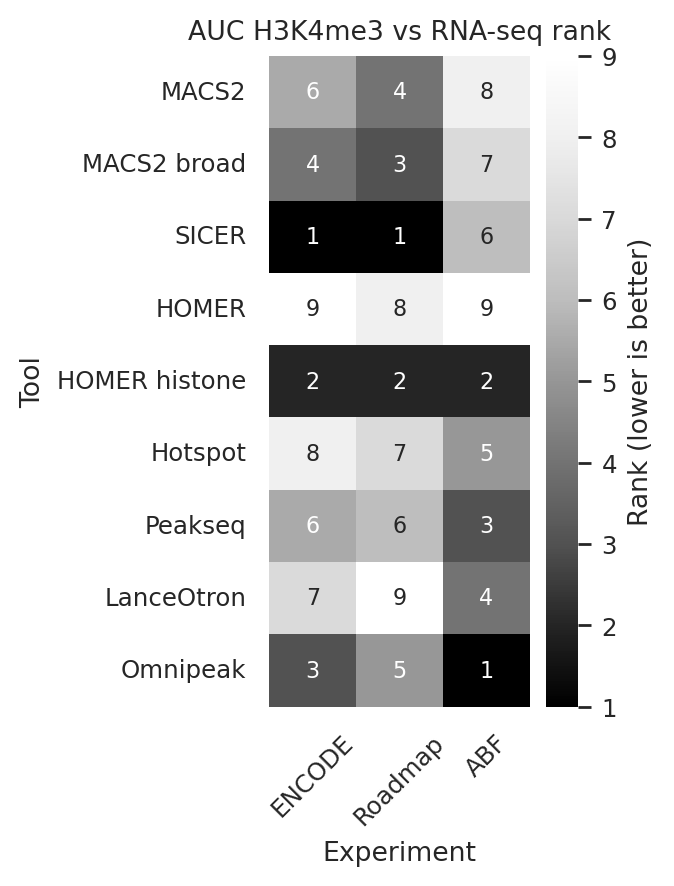

In [43]:
ts = []
for ds in ['ENCODE', 'Roadmap', 'ABF']:
    t = aps_df_ranked[aps_df_ranked['dataset'] == ds].copy().reset_index(drop=True)
    t['auc_rank'] = t['auc_rank'].rank(ascending=True)
    # Pivot to a wide form for heatmap
    t_mat = t.pivot(index='tool', columns='dataset', values='auc_rank')
    ts.append(t_mat)
t = pd.concat(ts, axis=1).loc[TOOLS]
# display(t)
plt.figure(figsize=(1.1 * t.shape[1], 0.5 * t.shape[0]))
ax = plt.axes()
sns.heatmap(
    t,
    annot=True,
    fmt='.0f',
    cmap='Greys_r',
    linecolor='white',
    cbar_kws={'label': 'Rank (lower is better)'},
    ax=ax
)
ax.xaxis.set_tick_params(rotation=45)
ax.set_xlabel('Experiment')
ax.set_ylabel('Tool')
ax.set_title('AUC H3K4me3 vs RNA-seq rank')
plt.tight_layout()
plt.show()


# Jaccard H3K36me3 vs expressed genes bodies

In [44]:
def genes_overlap(df_peaks, expression):
    rows = []
    for _, (c, r, tool, file) in tqdm(list(df_peaks[df_peaks['modification'] == 'H3K36me3']
                                           [['cell', 'replicate', 'tool', 'file']].iterrows())):
        # print(c, r, tool, file)
        if (c, r) not in expression:
            continue
        genes_file = pr.read_bed(sorted_file10(expression[c, r]))
        genes = len(genes_file)
        genes_len = genes_file.lengths().sum()
        peaks = lines(file)
        if peaks == 0:
            rows.append((c, r, tool, 0, 0, genes, genes_len, 0, 0, 0))
            continue
        peaks_file = pr.read_bed(sorted_file10(file))
        peaks_len = peaks_file.lengths().sum()
        peaks_overlap = len(peaks_file.overlap(genes_file))
        genes_overlap = len(genes_file.overlap(peaks_file))
        overlap_len = peaks_file.intersect(genes_file).lengths().sum()
        rows.append((c, r, tool,
                     peaks, peaks_len, genes, genes_len,
                     peaks_overlap, genes_overlap, overlap_len))

    df = pd.DataFrame(
        rows,
        columns=['cell', 'replicate', 'tool',
                 'peaks', 'peaks_len', 'genes', 'genes_len',
                 'peaks_overlap', 'genes_overlap', 'overlap_len'],
        dtype=object
    )
    df['precision'] = [d(a, b) for a, b in zip(df['peaks_overlap'], df['peaks'])]
    df['recall'] = [d(a, b) for a, b in zip(df['genes_overlap'], df['genes'])]
    df['f1'] = [d(2, d(1, s + 1e-10) + d(1, p + 1e-10))
                for s, p in zip(df['recall'], df['precision'])]

    df['jaccard'] = [
        d(o, p + g - o)
        for p, g, o in zip(df['peaks_len'], df['genes_len'], df['overlap_len'])
    ]
    return df

In [45]:
encode_genes_df_path = GSE26320_PATH + '/encode_genes_df.tsv'
encode_genes_df = load_or_compute(encode_genes_df_path, lambda: genes_overlap(df_encode_peaks, encode_expression))
encode_genes_df.sample(3)

,cell,replicate,tool,peaks,peaks_len,genes,genes_len,peaks_overlap,genes_overlap,overlap_len,precision,recall,f1,jaccard
26,HepG2,rep1,MACS2 broad,54590,27987373,11997,704566175,53142,8087,28370423,0.973475,0.674085,0.796578,0.040288
69,HMEC,rep2,HOMER,6921,913562,11986,755717600,6538,4305,896332,0.944661,0.359169,0.520456,0.001186
47,K562,rep2,SICER,39540,195618060,11959,680380039,37378,8801,190705216,0.945321,0.735931,0.827587,0.278283


ENCODE


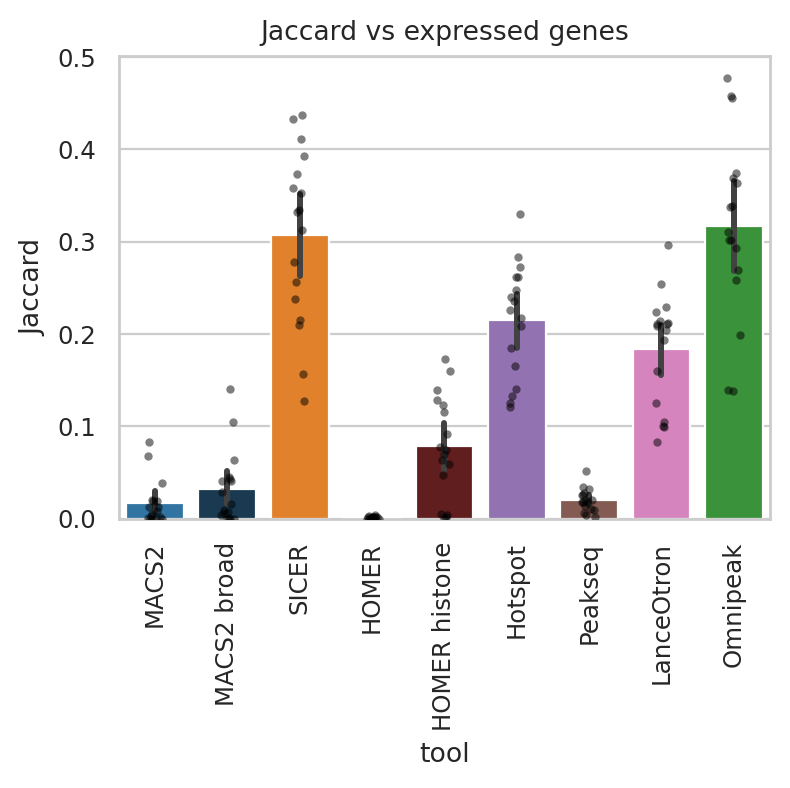

In [46]:
print('ENCODE')
plt.figure(figsize=(4, 4))
ax = plt.axes()
ax.title.set_text('Jaccard vs expressed genes')
sns.barplot(data=encode_genes_df, x='tool', y='jaccard',
            # capsize=.2, err_kws={'linewidth': 2},
            palette=TOOLS_PALETTE,
            order=TOOLS,
            ax=ax, )
sns.stripplot(data=encode_genes_df, x='tool', y='jaccard',
              dodge=True, size=3, color="black", alpha=0.5,
              order=TOOLS,
              ax=ax)
ax.xaxis.set_tick_params(rotation=90)
ax.set_ylabel('Jaccard')
plt.tight_layout()
plt.show()

In [47]:
immune_genes_df_path = IMMUNE_PATH + '/immune_genes_df.tsv'
immune_genes_df = load_or_compute(immune_genes_df_path, lambda: genes_overlap(df_immune_peaks, immune_expression))
immune_genes_df.fillna('', inplace=True)
immune_genes_df.sample(3)

,cell,replicate,tool,peaks,peaks_len,genes,genes_len,peaks_overlap,genes_overlap,overlap_len,precision,recall,f1,jaccard
4,BCell,,MACS2 broad,152502,217568779,11985,673753610,142054,10323,214666657,0.931489,0.861327,0.895035,0.317246
3,Monocyte,,MACS2 broad,105833,199110989,11986,661756110,98569,9966,195925814,0.931364,0.831470,0.878587,0.294651
0,Monocyte,,MACS2,127115,167040107,11986,661756110,119586,9766,165418396,0.940770,0.814784,0.873256,0.249358


Roadmap


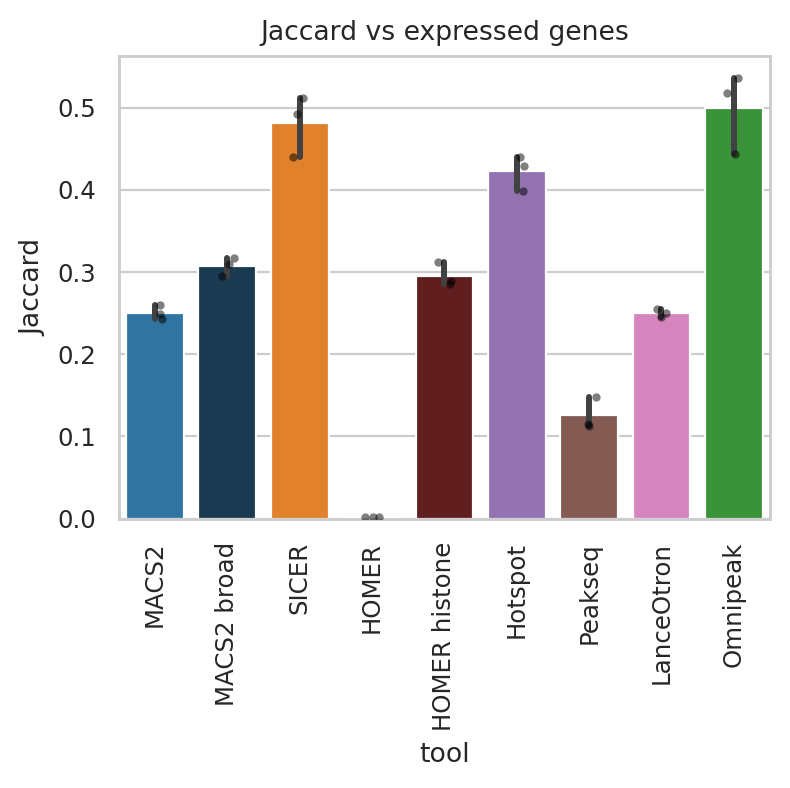

In [48]:
print('Roadmap')
plt.figure(figsize=(4, 4))
ax = plt.axes()
ax.title.set_text('Jaccard vs expressed genes')
sns.barplot(data=immune_genes_df, x='tool', y='jaccard',
            # capsize=.2, err_kws={'linewidth': 2},
            palette=TOOLS_PALETTE,
            order=TOOLS,
            ax=ax)
sns.stripplot(data=immune_genes_df, x='tool', y='jaccard',
              dodge=True, size=3, color="black", alpha=0.5,
              order=TOOLS,
              ax=ax)
ax.xaxis.set_tick_params(rotation=90)
ax.set_ylabel('Jaccard')
plt.tight_layout()
plt.show()

In [49]:
abf_genes_df_path = ABF_PATH + '/abf_genes_df.tsv'
abf_genes_df = load_or_compute(abf_genes_df_path, lambda: genes_overlap(df_abf_peaks, abf_expression))
abf_genes_df.sample(3)

,cell,replicate,tool,peaks,peaks_len,genes,genes_len,peaks_overlap,genes_overlap,overlap_len,precision,recall,f1,jaccard
28,OD,OD1,MACS2 broad,295309,119048829,11993,707210031,277640,9950,117646593,0.940168,0.829651,0.881459,0.166024
103,YD,YD15,HOMER,827,1043674,11994,718497804,763,783,986594,0.922612,0.065283,0.121937,0.001373
53,OD,OD5,SICER,34236,432555164,11962,712470524,29190,10808,389129802,0.852611,0.903528,0.877331,0.514793


ABF


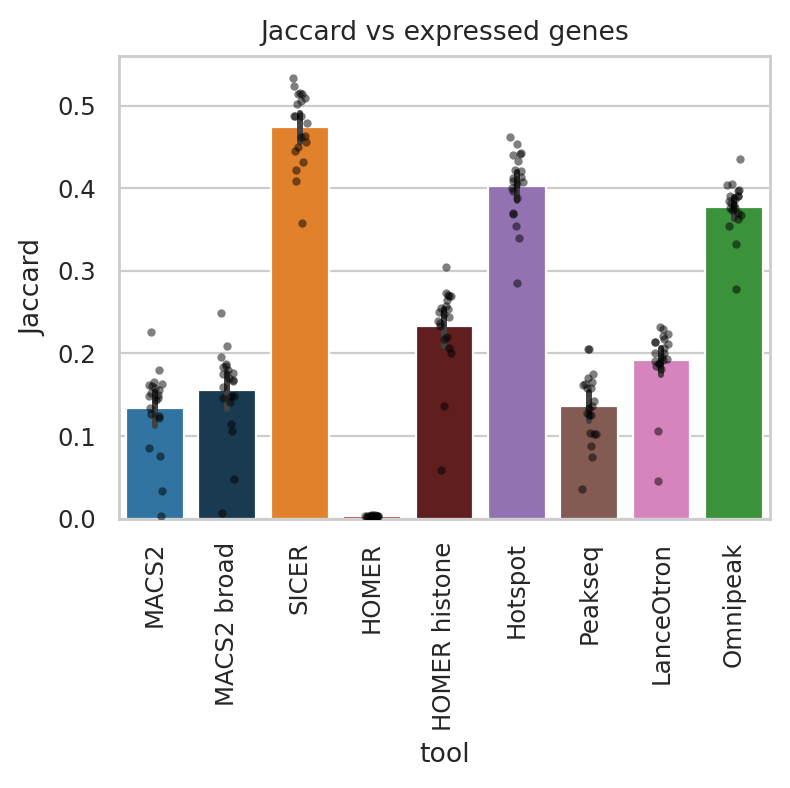

In [50]:
print('ABF')
plt.figure(figsize=(4, 4))
ax = plt.axes()
ax.title.set_text('Jaccard vs expressed genes')
sns.barplot(data=abf_genes_df, x='tool', y='jaccard',
            # capsize=.2, err_kws={'linewidth': 2},
            palette=TOOLS_PALETTE,
            order=TOOLS,
            ax=ax)
sns.stripplot(data=abf_genes_df, x='tool', y='jaccard',
              dodge=True, size=3, color="black", alpha=0.5,
              order=TOOLS,
              ax=ax)
ax.xaxis.set_tick_params(rotation=90)
ax.set_ylabel('Jaccard')
plt.tight_layout()
plt.show()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

ENCODE_LanceOtron vs. ENCODE_Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:2.283e-04 U_stat=3.700e+01
ABF_LanceOtron vs. ABF_Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:3.125e-08 U_stat=0.000e+00
ENCODE_Peakseq vs. ENCODE_Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:7.054e-07 U_stat=0.000e+00
ABF_Peakseq vs. ABF_Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:3.125e-08 U_stat=0.000e+00
ABF_Hotspot vs. ABF_Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:7.110e-03 U_stat=3.280e+02
ENCODE_Hotspot vs. ENCODE_Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P

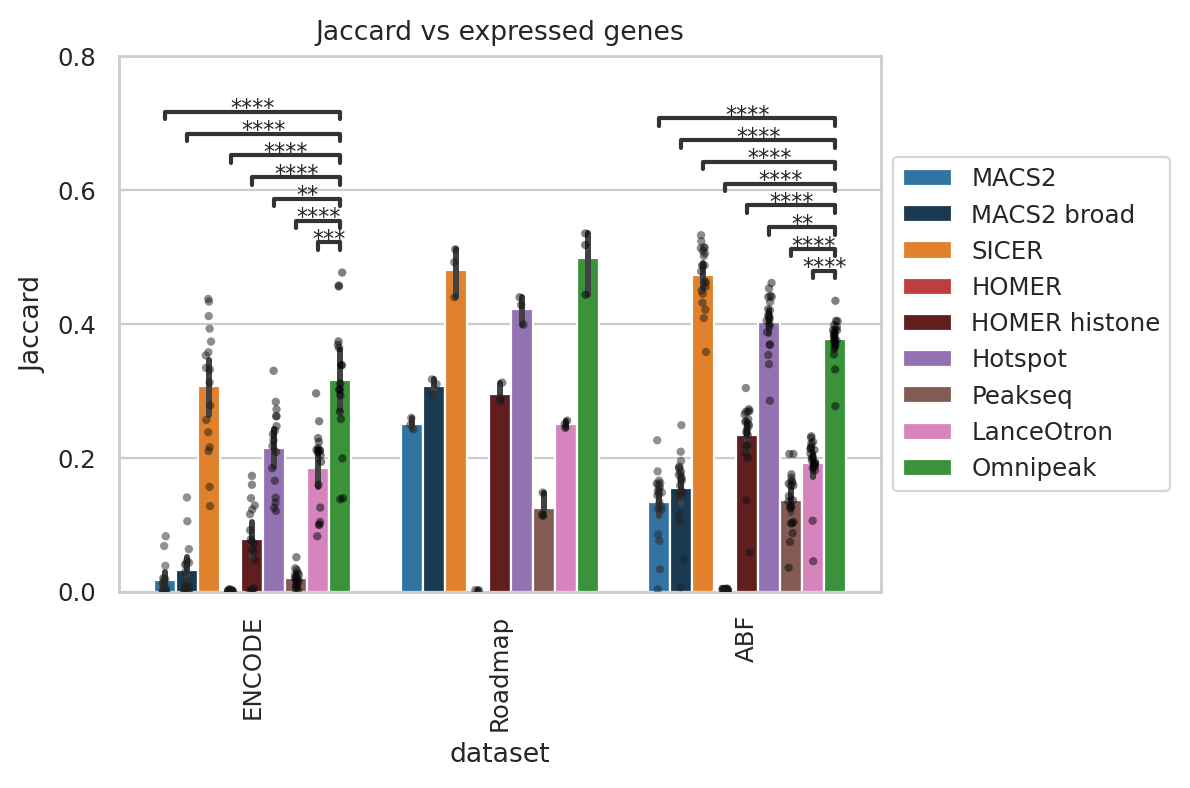

In [51]:
encode_genes_df['dataset'] = 'ENCODE'
immune_genes_df['dataset'] = 'Roadmap'
abf_genes_df['dataset'] = 'ABF'
t = pd.concat([encode_genes_df, immune_genes_df, abf_genes_df]).reset_index(drop=True)

plt.figure(figsize=(6, 4))
ax = plt.axes()
ax.title.set_text('Jaccard vs expressed genes')
sns.barplot(data=t, x='dataset', y='jaccard', hue='tool',
            # capsize=0.2, err_kws={'linewidth': 2},
            palette=TOOLS_PALETTE,
            order=datasets,
            hue_order=TOOLS,
            ax=ax)
sns.stripplot(data=t, x='dataset', y='jaccard', hue='tool',
              dodge=True, size=3, color="black", alpha=0.5, palette='dark:black',
              order=datasets,
              hue_order=TOOLS, legend=False,
              ax=ax)
ax.xaxis.set_tick_params(rotation=90)
ax.set_ylabel('Jaccard')
# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

pairs = [((ds, tl), (ds, 'Omnipeak')) for ds, tl in
         product(datasets, [tool for tool in TOOLS if tool != 'Omnipeak'])]  # which groups to compare
annot = Annotator(ax, pairs, data=t, x='dataset', y='jaccard', hue='tool', order=datasets, hue_order=TOOLS)
annot.configure(test='Mann-Whitney', comparisons_correction="BH", correction_format="replace",
                hide_non_significant=True,
                verbose=2,
                text_offset=-3, line_offset=0)
annot.apply_test()
annot.annotate()

ax.set_yticks(np.arange(0, 0.9, step=0.2), minor=False)

plt.tight_layout()
plt.show()

## Ranks

In [52]:
genes_df_ranked = t[['dataset', 'cell', 'replicate',  'tool', 'jaccard']].copy()
genes_df_ranked['jaccard_rank'] = (
    genes_df_ranked
    .groupby(['dataset', 'cell', 'replicate'], group_keys=False)['jaccard']
    .rank(method='min', ascending=False)
)
genes_df_ranked = genes_df_ranked[['dataset', 'tool', 'jaccard_rank']].groupby(['dataset', 'tool']).mean().reset_index()
genes_df_ranked.sample(5)

,dataset,tool,jaccard_rank
4,ABF,MACS2,7.428571
24,Roadmap,Omnipeak,1.000000
16,ENCODE,Peakseq,6.647059
1,ABF,HOMER histone,4.000000
21,Roadmap,LanceOtron,6.333333


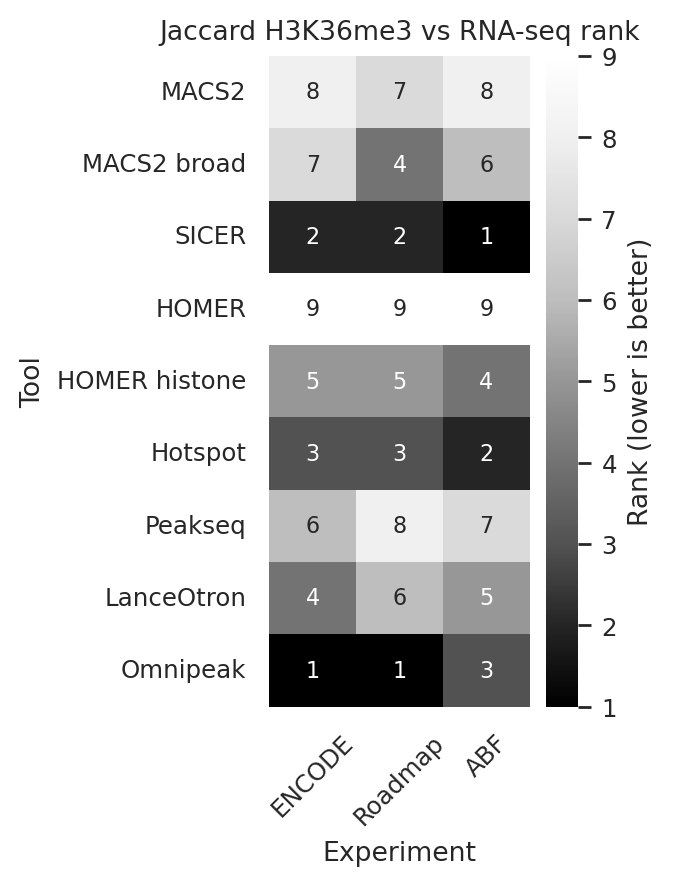

In [53]:
ts = []
for ds in ['ENCODE', 'Roadmap', 'ABF']:
    t = genes_df_ranked[genes_df_ranked['dataset'] == ds].copy().reset_index(drop=True)
    t['jaccard_rank'] = t['jaccard_rank'].rank(ascending=True)
    # Pivot to a wide form for heatmap
    t_mat = t.pivot(index='tool', columns='dataset', values='jaccard_rank')
    ts.append(t_mat)
t = pd.concat(ts, axis=1).loc[TOOLS]
# display(t)
plt.figure(figsize=(1.1 * t.shape[1], 0.5 * t.shape[0]))
ax = plt.axes()
sns.heatmap(
    t,
    annot=True,
    fmt='.0f',
    cmap='Greys_r',
    linecolor='white',
    cbar_kws={'label': 'Rank (lower is better)'},
    ax=ax
)
ax.xaxis.set_tick_params(rotation=45)
ax.set_xlabel('Experiment')
ax.set_ylabel('Tool')
ax.set_title('Jaccard H3K36me3 vs RNA-seq rank')
plt.tight_layout()
plt.show()


# Compare ratio of peaks to genes

In [54]:
import tempfile


def genes_peaks_ratio(df_peaks, expression):
    tf = tempfile.mktemp()

    rows = []
    for _, (c, r, tool, file) in tqdm(list(df_peaks[df_peaks['modification'] == 'H3K36me3']
                                           [['cell', 'replicate', 'tool', 'file']].iterrows())):
        # print(c, r, tool, file)
        if (c, r) not in expression:
            continue
        genes_file = sorted_file(expression[c, r])
        peaks_file = sorted_file(file)
        ! echo "" > {tf}
        ! bedtools intersect -a {genes_file} -b {peaks_file} -wa -wb > {tf}
        expr_cols = len(pd.read_csv(genes_file, sep='\t', header=None, nrows=1).columns)
        try:
            tf_expression = pd.read_csv(tf, sep='\t', header=None)
            genes = len(tf_expression.groupby([0, 1, 2]).count())
            peaks = len(tf_expression.groupby([expr_cols, expr_cols + 1, expr_cols + 2]).count())
            rows.append((c, r, tool, genes, peaks))
        except:
            pass

    df = pd.DataFrame(
        rows,
        columns=['cell', 'replicate', 'tool', 'genes', 'peaks'],
        dtype=object
    )
    df['peaks_to_genes'] = df['peaks'] / df['genes']
    return df

In [55]:
encode_genes_ratios_path = GSE26320_PATH + '/encode_genes_ratios.tsv'
encode_genes_ratios = load_or_compute(encode_genes_ratios_path,
                                      lambda: genes_peaks_ratio(df_encode_peaks, encode_expression))
encode_genes_ratios.sample(3)

,cell,replicate,tool,genes,peaks,peaks_to_genes
27,HepG2,rep2,MACS2 broad,1698,4361,2.568316
111,NHLF,rep1,Hotspot,11040,267430,24.223732
58,Huvec,rep2,Omnipeak,9575,34384,3.591018


ENCODE


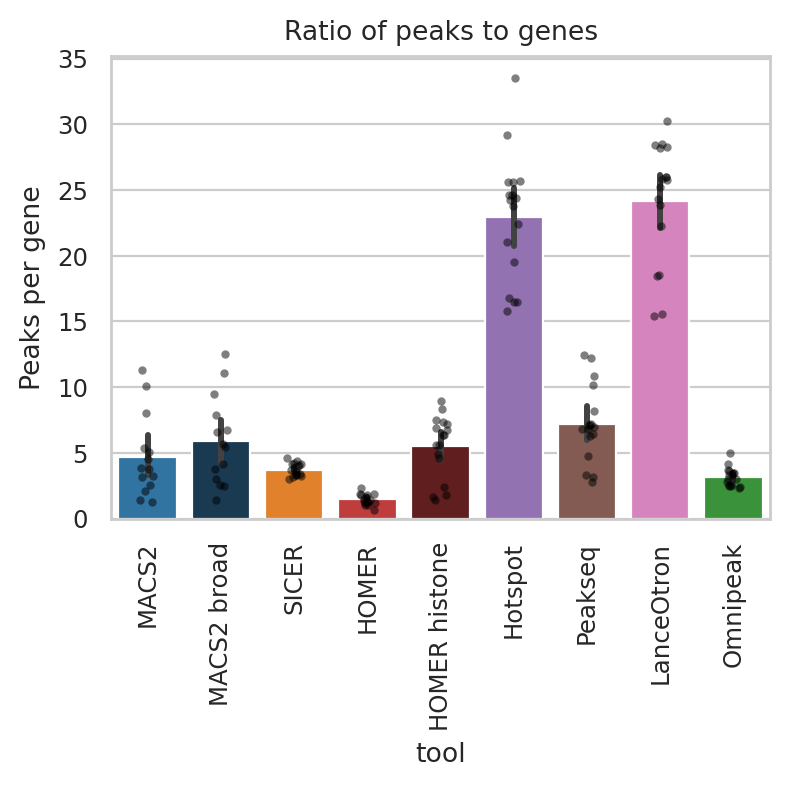

In [56]:
print('ENCODE')
plt.figure(figsize=(4, 4))
ax = plt.axes()
sns.barplot(data=encode_genes_ratios, y='peaks_to_genes', x='tool',
            # capsize=.2, err_kws={'linewidth': 2},
            palette=TOOLS_PALETTE,
            order=TOOLS,
            ax=ax)
sns.stripplot(data=encode_genes_ratios, y='peaks_to_genes', x='tool',
              dodge=True, size=3, color="black", alpha=0.5,
              order=TOOLS,
              ax=ax)
ax.set_ylabel('Peaks per gene')
ax.title.set_text('Ratio of peaks to genes')
ax.xaxis.set_tick_params(rotation=90)
plt.tight_layout()
plt.show()

In [57]:
immune_genes_ratios_path = IMMUNE_PATH + '/immune_genes_ratios.tsv'
immune_genes_ratios = load_or_compute(immune_genes_ratios_path,
                                      lambda: genes_peaks_ratio(df_immune_peaks, immune_expression))
immune_genes_ratios.fillna('', inplace=True)
immune_genes_ratios.sample(3)

,cell,replicate,tool,genes,peaks,peaks_to_genes
12,TCell,,HOMER,4689,8865,1.890595
25,Monocyte,,LanceOtron,10063,219546,21.817152
14,BCell,,HOMER,3522,5280,1.499148


Immune


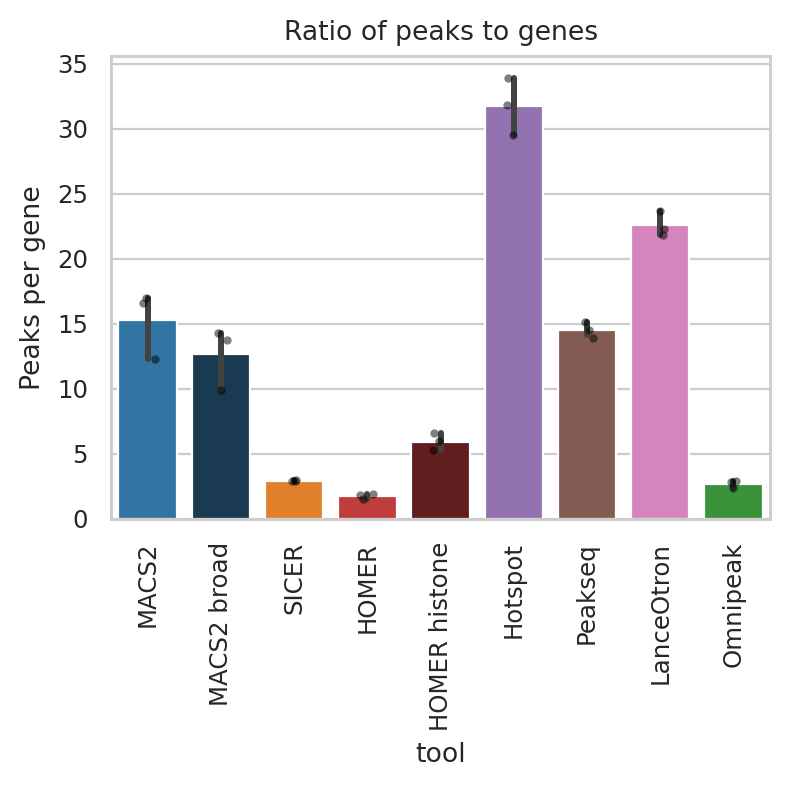

In [58]:
print('Immune')
plt.figure(figsize=(4, 4))
ax = plt.axes()
sns.barplot(data=immune_genes_ratios, y='peaks_to_genes', x='tool',
            # capsize=.2, err_kws={'linewidth': 2},
            palette=TOOLS_PALETTE,
            order=TOOLS,
            ax=ax)
sns.stripplot(data=immune_genes_ratios, y='peaks_to_genes', x='tool',
              dodge=True, size=3, color="black", alpha=0.5,
              order=TOOLS,
              ax=ax)
ax.set_ylabel('Peaks per gene')
ax.title.set_text('Ratio of peaks to genes')
ax.xaxis.set_tick_params(rotation=90)
plt.tight_layout()
plt.show()

In [59]:
abf_genes_ratios_path = ABF_PATH + '/abf_genes_ratios.tsv'
abf_genes_ratios = load_or_compute(abf_genes_ratios_path,
                                   lambda: genes_peaks_ratio(df_abf_peaks, abf_expression))
abf_genes_ratios.sample(3)

,cell,replicate,tool,genes,peaks,peaks_to_genes
70,OD,OD16,Omnipeak,10515,28154,2.677508
61,OD,OD11,SICER,10770,32624,3.029155
129,OD,OD10,Hotspot,11442,409577,35.795927


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

ENCODE_LanceOtron vs. ENCODE_Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:7.054e-07 U_stat=2.890e+02
ABF_LanceOtron vs. ABF_Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:3.125e-08 U_stat=4.410e+02
ENCODE_Peakseq vs. ENCODE_Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:4.153e-05 U_stat=2.640e+02
ABF_Peakseq vs. ABF_Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:3.125e-08 U_stat=4.410e+02
ABF_Hotspot vs. ABF_Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:3.125e-08 U_stat=4.410e+02
ENCODE_Hotspot vs. ENCODE_Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P

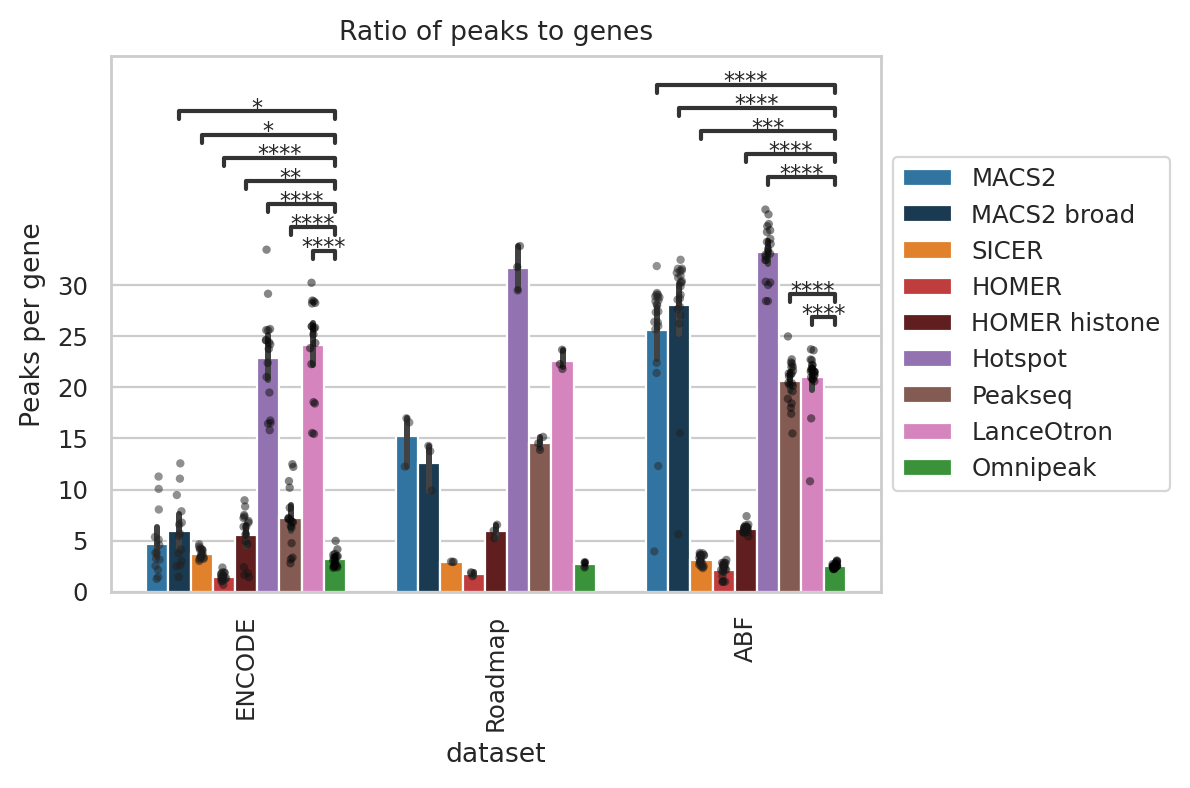

In [60]:
from itertools import product

encode_genes_ratios['dataset'] = 'ENCODE'
immune_genes_ratios['dataset'] = 'Roadmap'
abf_genes_ratios['dataset'] = 'ABF'
t = pd.concat([encode_genes_ratios, immune_genes_ratios, abf_genes_ratios]).reset_index(drop=True)
t['peaks_to_genes'] = t['peaks_to_genes'].astype(float)

plt.figure(figsize=(6, 4))
ax = plt.axes()
sns.barplot(data=t, y='peaks_to_genes', x='dataset', hue='tool',
            # capsize=.2, err_kws={'linewidth': 2},
            palette=TOOLS_PALETTE,
            order=datasets,
            hue_order=TOOLS,
            ax=ax)
sns.stripplot(data=t, y='peaks_to_genes', x='dataset', hue='tool',
              dodge=True, size=3, color="black", alpha=0.5, palette='dark:black',
              order=datasets,
              hue_order=TOOLS, legend=False,
              ax=ax)
ax.set_ylabel('Peaks per gene')
ax.title.set_text('Ratio of peaks to genes')
ax.xaxis.set_tick_params(rotation=90)
# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

pairs = [((ds, tl), (ds, 'Omnipeak')) for ds, tl in
         product(datasets, [tool for tool in TOOLS if tool != 'Omnipeak'])]  # which groups to compare
annot = Annotator(ax, pairs, data=t, x='dataset', y='peaks_to_genes', hue='tool', order=datasets, hue_order=TOOLS)
annot.configure(test='Mann-Whitney', comparisons_correction="BH", correction_format="replace",
                hide_non_significant=True,
                verbose=2,
                text_offset=-3, line_offset=0)
annot.apply_test()
annot.annotate()

ax.set_yticks(np.arange(0, 31, step=5), minor=False)

plt.tight_layout()
plt.show()

# END